<a href="https://www.kaggle.com/code/lalit7881/sleep-debt-screen-time-100-beats?scriptVersionId=353107143" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/samartalwar/sleep-debt-and-screen-time-late-night-phone-habits/bedtime_screentime_sleep_debt.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/samartalwar/sleep-debt-and-screen-time-late-night-phone-habits/bedtime_screentime_sleep_debt.csv")

In [3]:
df.head()

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt


In [4]:
df.tail()

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
8495,USR-08496,61,Female,Remote Tech,Night Owl,18,Streaming (Netflix/Hulu),61,1,60,74,21.0,5.57,26.5,18.1,3,3.2,Moderate Debt
8496,USR-08497,64,Male,Student,Night Owl,138,TikTok / Reels,58,1,0,58,84.3,3.99,20.4,19.4,7,10.0,Severe Sleep Debt
8497,USR-08498,34,Male,Corporate 9-to-5,Intermediate,56,Streaming (Netflix/Hulu),56,0,94,33,40.6,7.58,17.4,20.7,2,3.7,Mild Deficit
8498,USR-08499,23,Male,Healthcare / Shift Worker,Night Owl,165,TikTok / Reels,72,0,0,52,123.3,3.20,14.2,15.8,7,10.0,Severe Sleep Debt
8499,USR-08500,27,Female,Student,Night Owl,108,Instagram / Reddit,35,1,0,23,55.7,4.04,27.3,18.7,5,6.7,Moderate Debt


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   object 
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   object 
 3   occupation_type           8500 non-null   object 
 4   chronotype                8500 non-null   object 
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   object 
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_slee

In [6]:
df.describe()

,age,bedtime_phone_minutes,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score
count,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000
mean,34.355647,59.250000,55.153882,0.467765,33.222471,35.701412,40.671471,6.266209,21.735741,19.105859,2.766000,3.794671
std,11.584259,36.931991,19.850550,0.498989,51.935645,20.819390,17.444914,1.446258,3.069377,2.546459,1.695407,2.685153
min,18.000000,1.000000,10.000000,0.000000,0.000000,0.000000,6.000000,3.200000,8.100000,9.600000,0.000000,1.000000
25%,25.000000,31.000000,42.000000,0.000000,0.000000,21.000000,28.200000,5.240000,19.700000,17.400000,2.000000,1.100000
50%,32.000000,51.000000,55.000000,0.000000,0.000000,35.000000,37.600000,6.330000,21.900000,19.100000,3.000000,3.200000
75%,42.000000,79.000000,69.000000,1.000000,55.000000,50.000000,49.700000,7.350000,23.900000,20.800000,4.000000,5.600000
max,65.000000,180.000000,100.000000,1.000000,250.000000,112.000000,123.300000,9.800000,28.000000,27.000000,7.000000,10.000000


In [7]:
df .isnull().sum()

user_id                     0
age                         0
gender                      0
occupation_type             0
chronotype                  0
bedtime_phone_minutes       0
primary_bedtime_app         0
screen_brightness_pct       0
blue_light_filter_active    0
caffeine_post_5pm_mg        0
physical_activity_min       0
sleep_latency_min           0
total_sleep_hours           0
deep_sleep_pct              0
rem_sleep_pct               0
morning_alarm_snoozes       0
next_day_fatigue_score      0
sleep_debt_category         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

user_id                      object
age                           int64
gender                       object
occupation_type              object
chronotype                   object
bedtime_phone_minutes         int64
primary_bedtime_app          object
screen_brightness_pct         int64
blue_light_filter_active      int64
caffeine_post_5pm_mg          int64
physical_activity_min         int64
sleep_latency_min           float64
total_sleep_hours           float64
deep_sleep_pct              float64
rem_sleep_pct               float64
morning_alarm_snoozes         int64
next_day_fatigue_score      float64
sleep_debt_category          object
dtype: object

In [10]:
df.shape


(8500, 18)

In [11]:
df.nunique

<bound method DataFrame.nunique of         user_id  age      gender            occupation_type    chronotype  \
0     USR-00001   29      Female  Healthcare / Shift Worker  Intermediate   
1     USR-00002   58      Female                    Student  Intermediate   
2     USR-00003   41      Female  Healthcare / Shift Worker     Night Owl   
3     USR-00004   36  Non-Binary                Remote Tech  Intermediate   
4     USR-00005   23      Female  Healthcare / Shift Worker  Intermediate   
...         ...  ...         ...                        ...           ...   
8495  USR-08496   61      Female                Remote Tech     Night Owl   
8496  USR-08497   64        Male                    Student     Night Owl   
8497  USR-08498   34        Male           Corporate 9-to-5  Intermediate   
8498  USR-08499   23        Male  Healthcare / Shift Worker     Night Owl   
8499  USR-08500   27      Female                    Student     Night Owl   

      bedtime_phone_minutes       primar

In [12]:
df.columns

Index(['user_id', 'age', 'gender', 'occupation_type', 'chronotype',
       'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct',
       'blue_light_filter_active', 'caffeine_post_5pm_mg',
       'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours',
       'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes',
       'next_day_fatigue_score', 'sleep_debt_category'],
      dtype='object')

## EDA

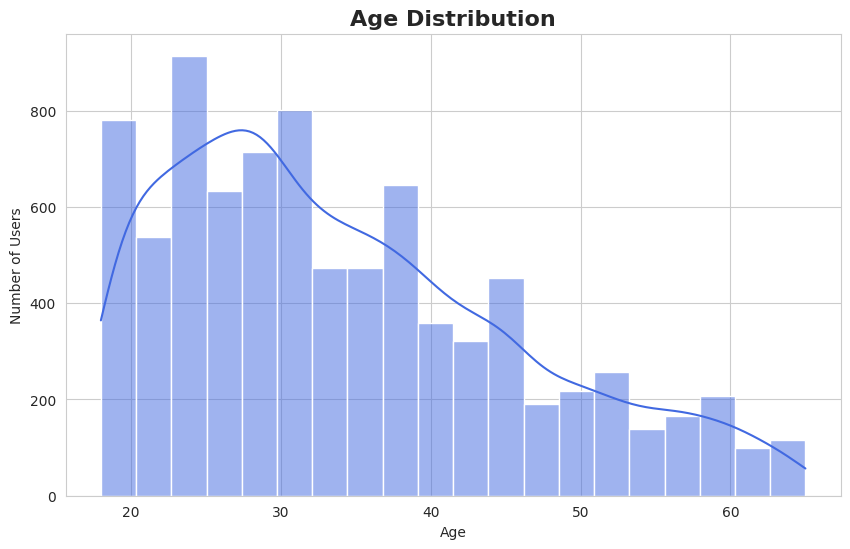

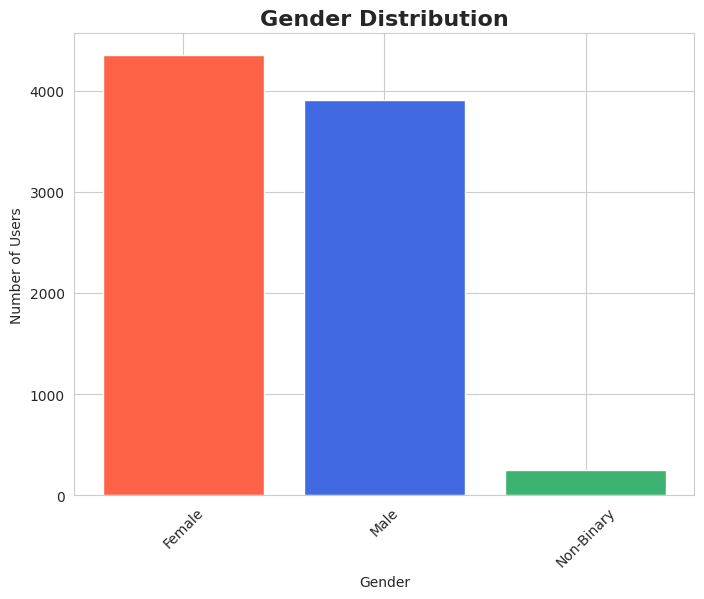

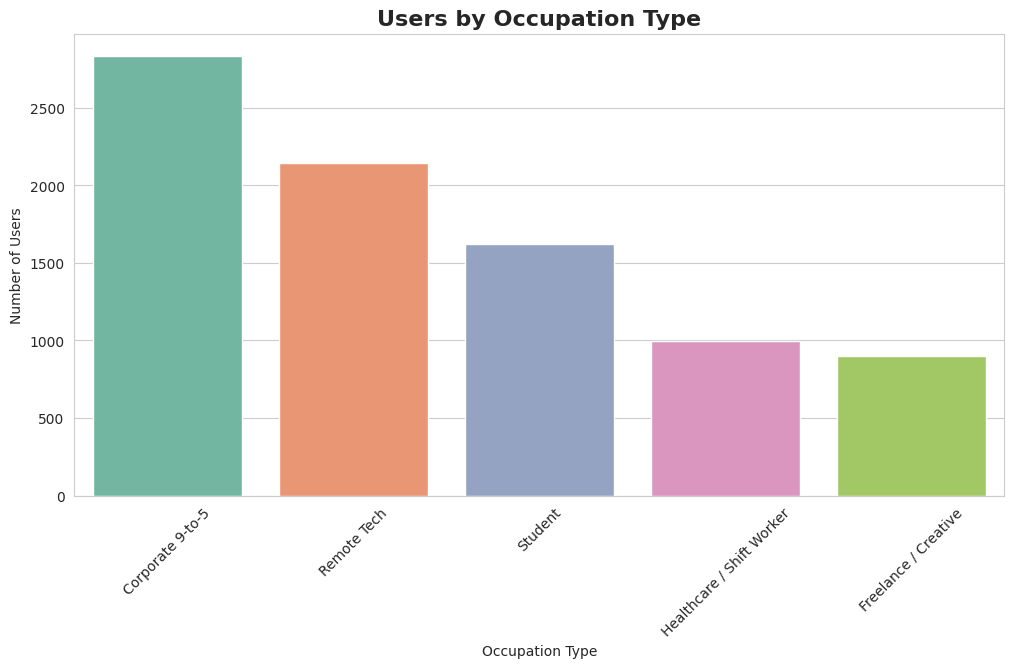

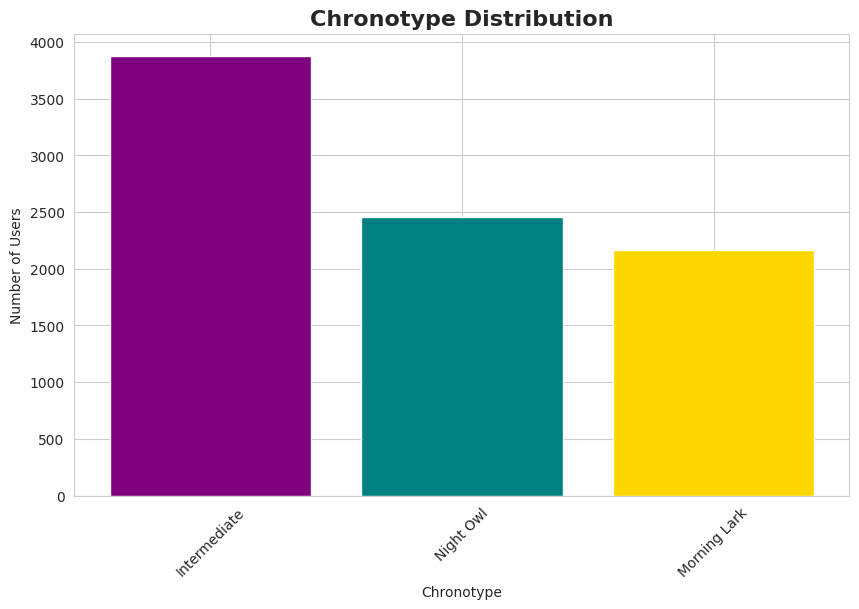

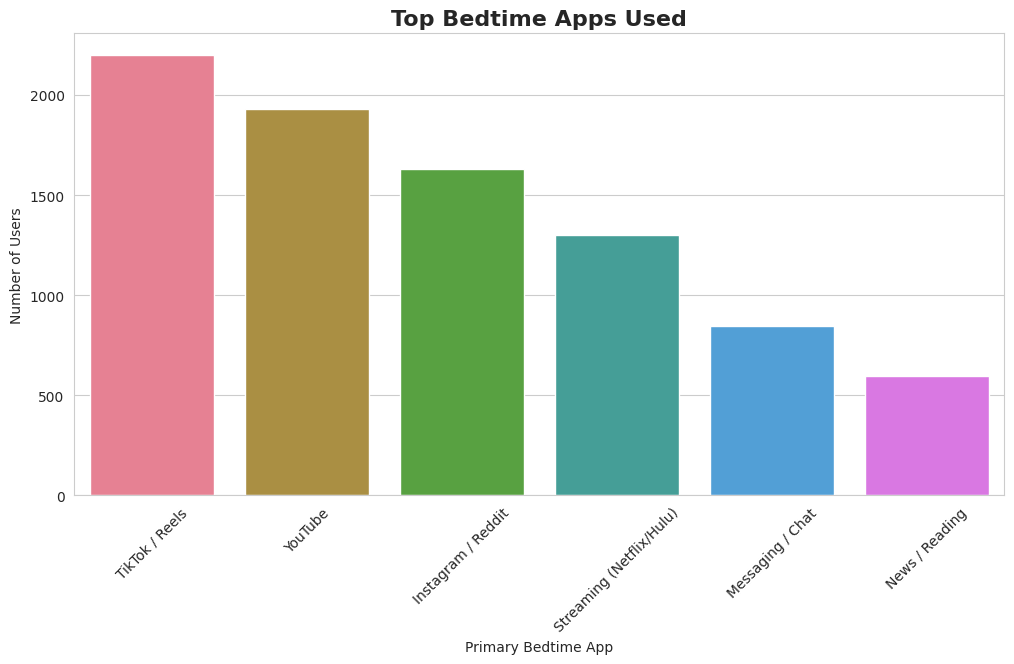

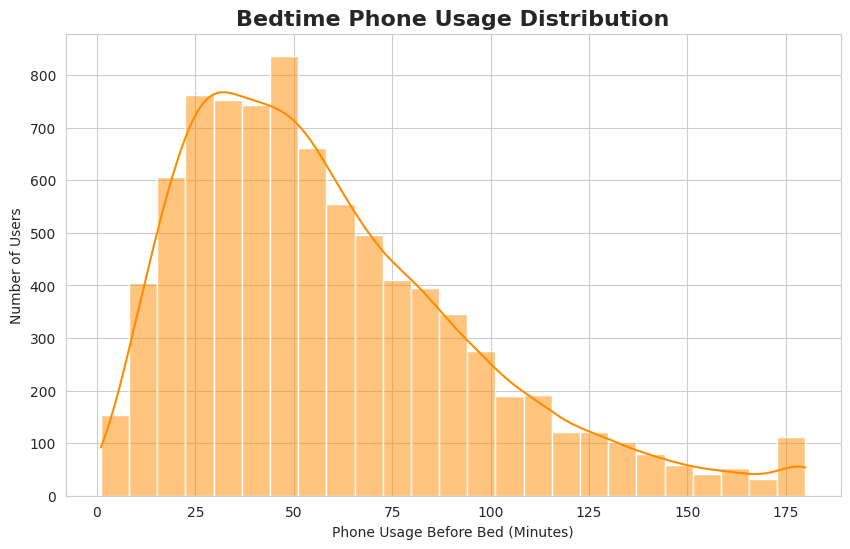

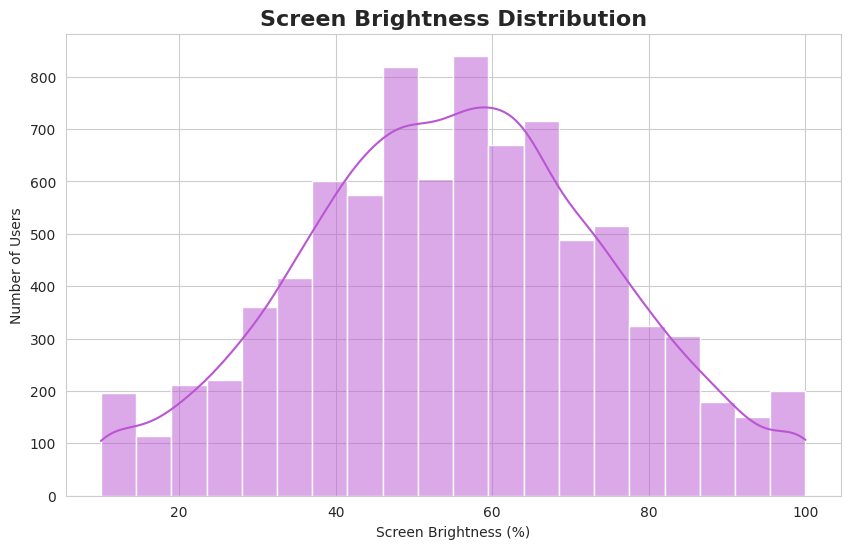

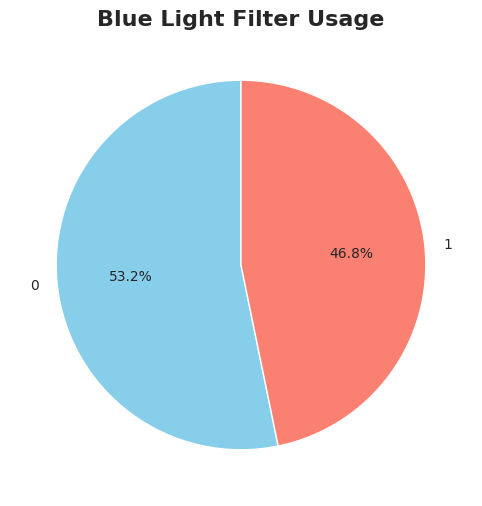

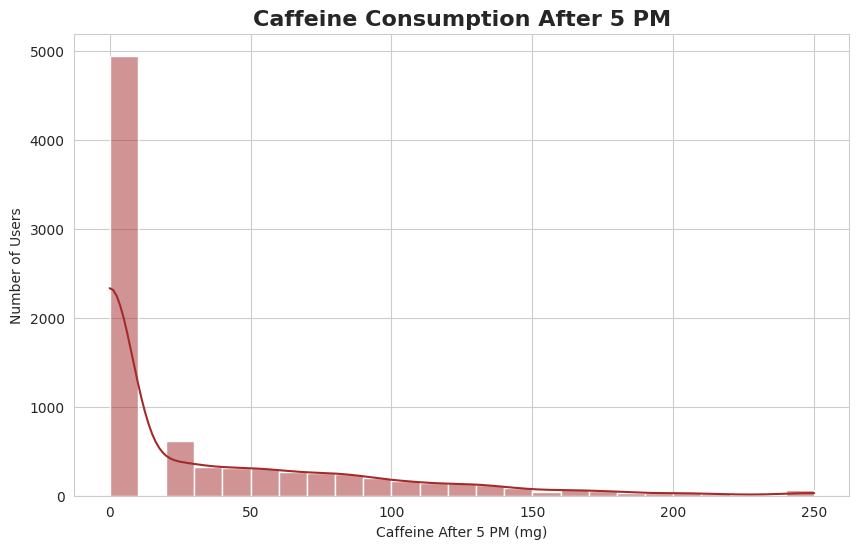

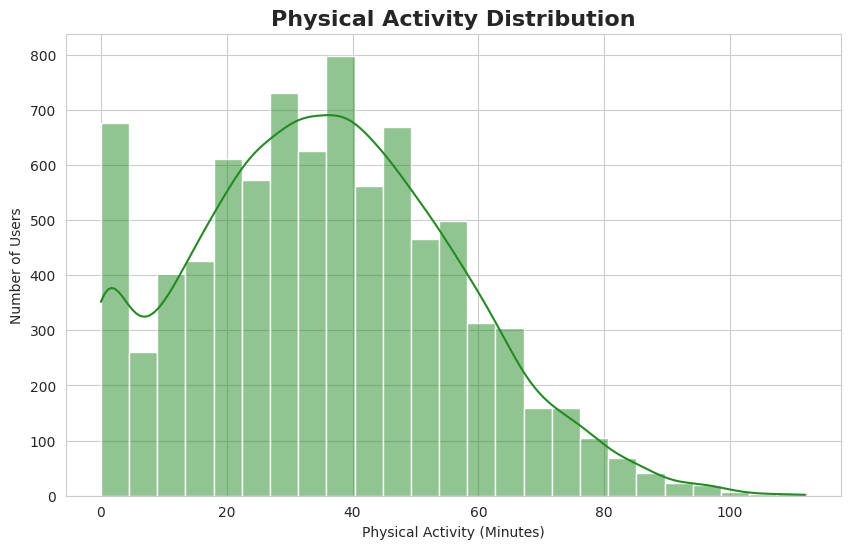

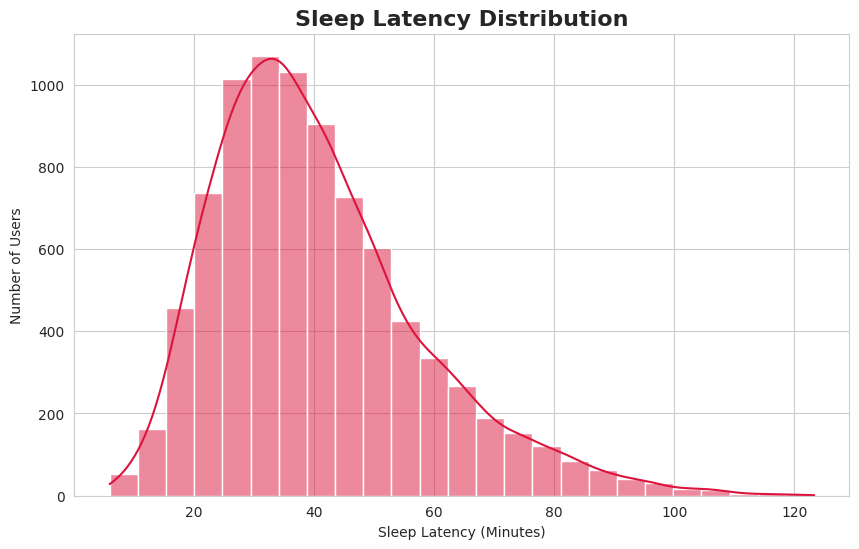

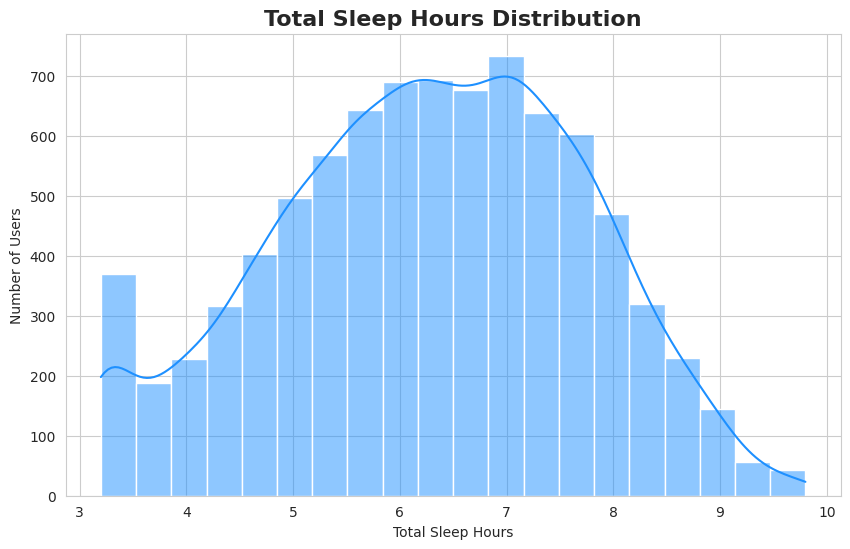

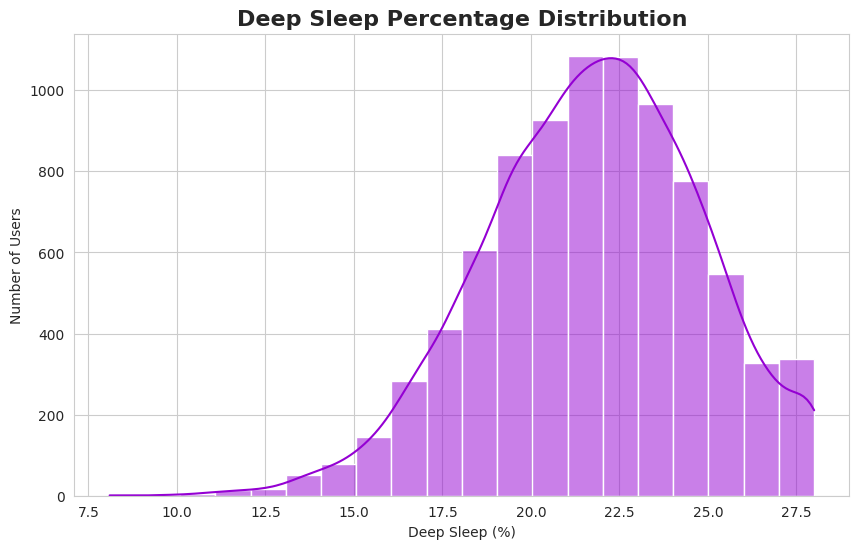

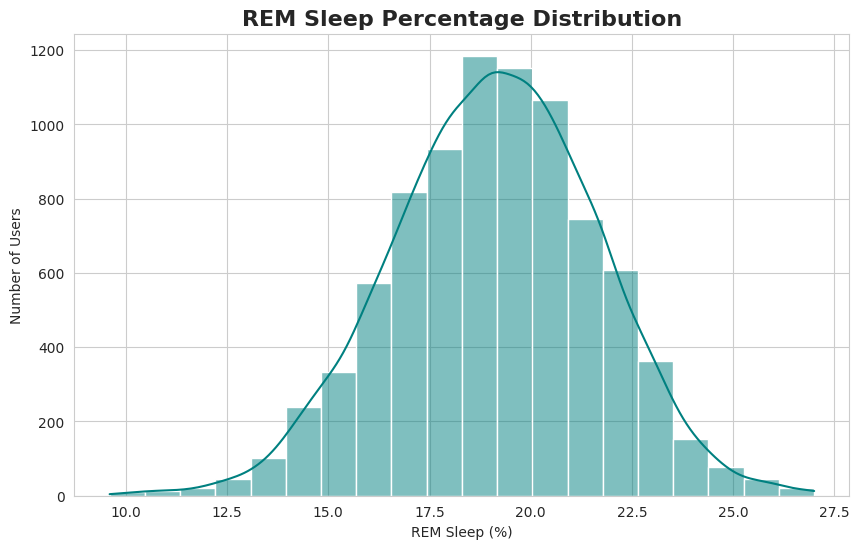

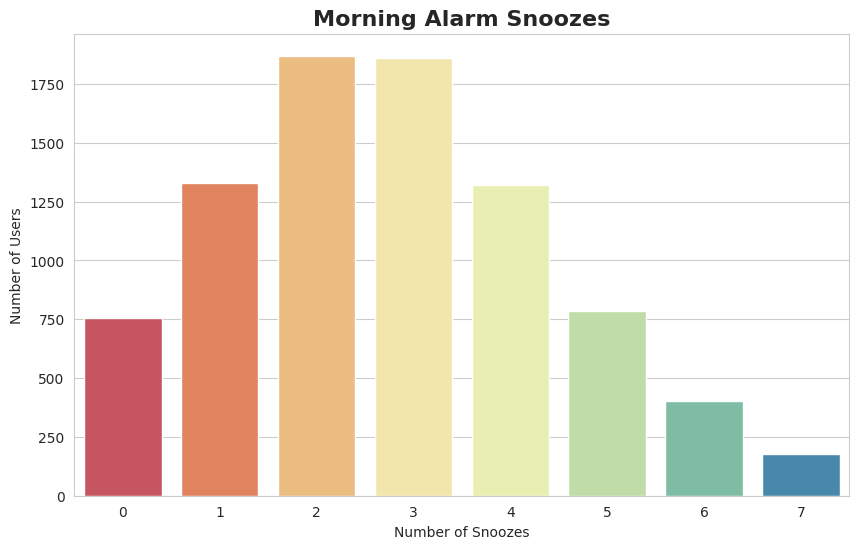

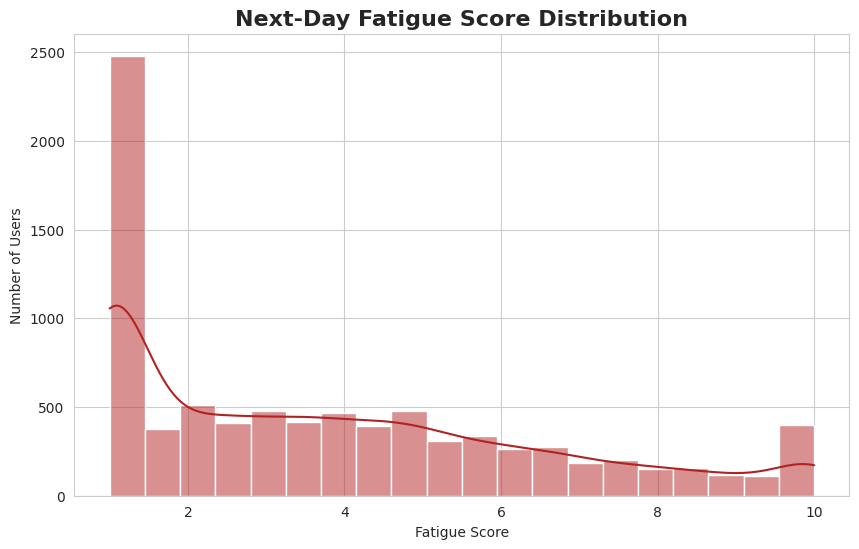

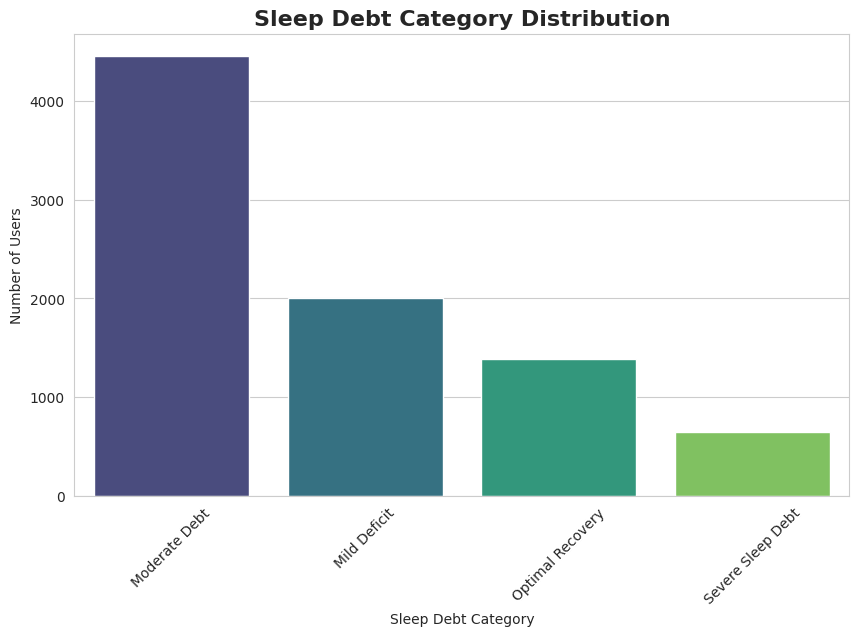

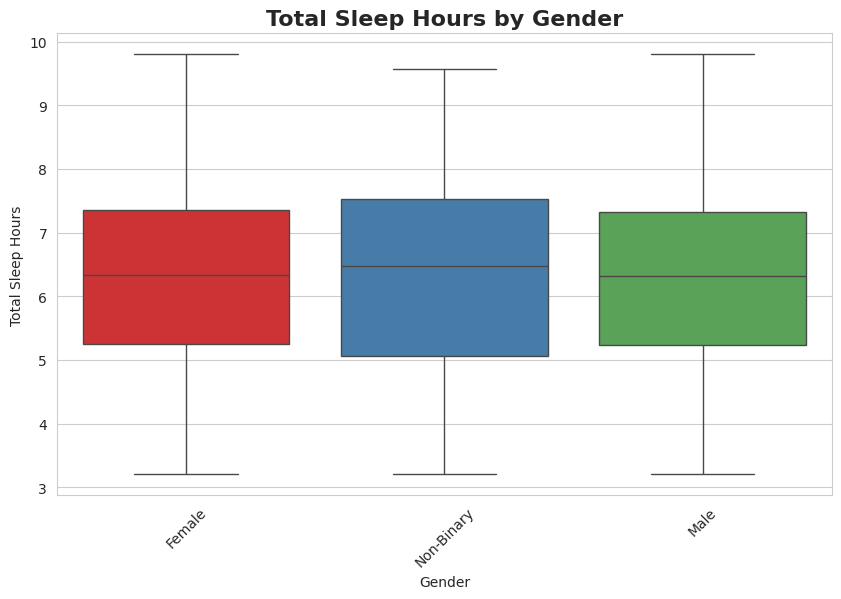

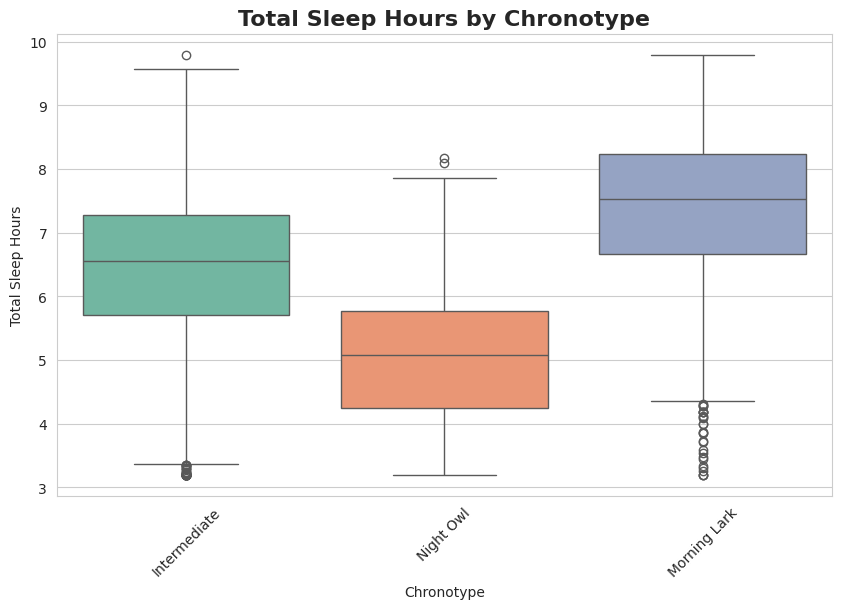

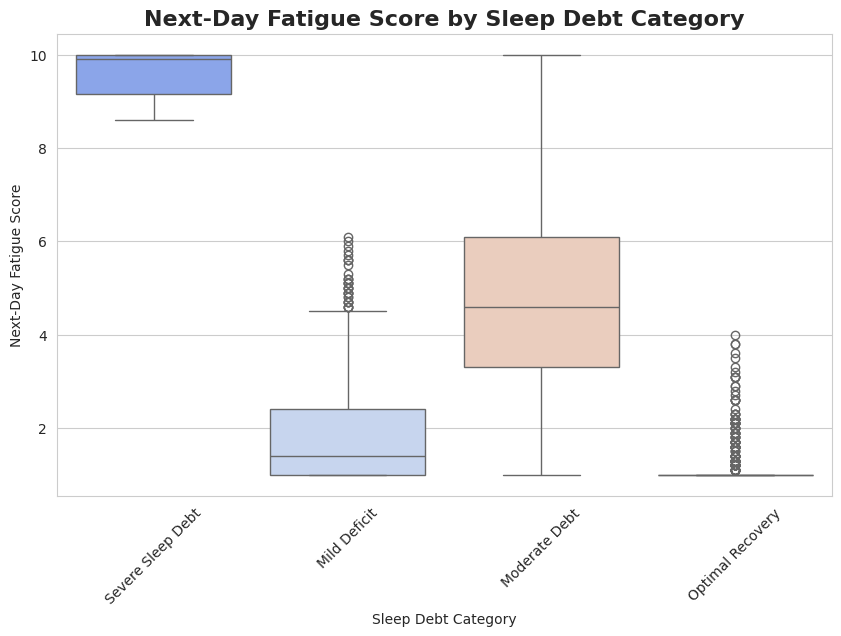

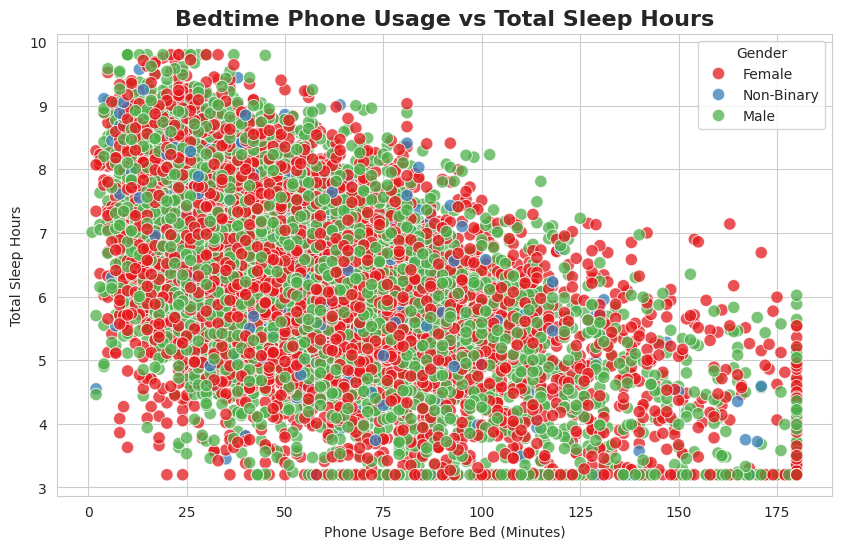

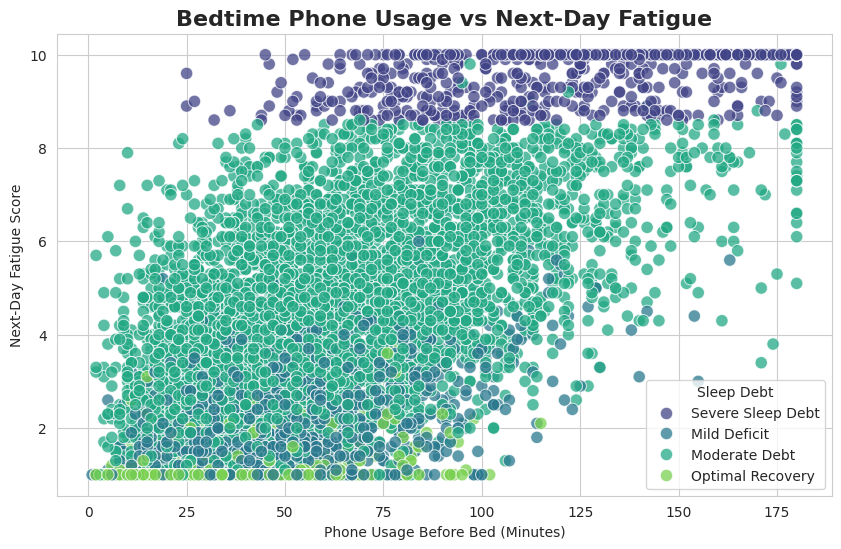

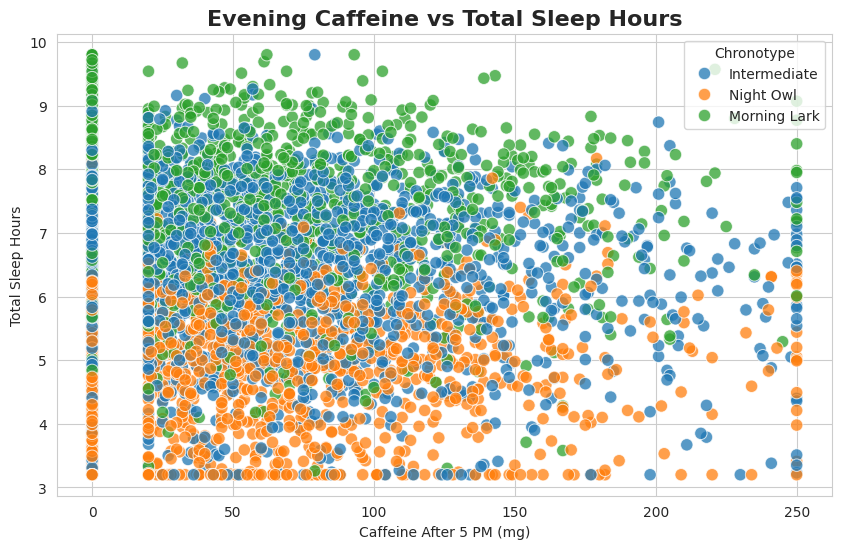

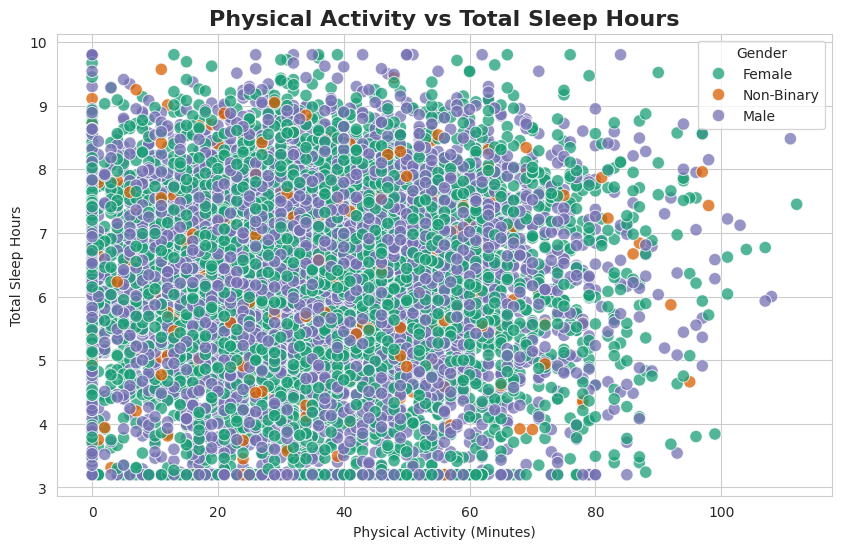

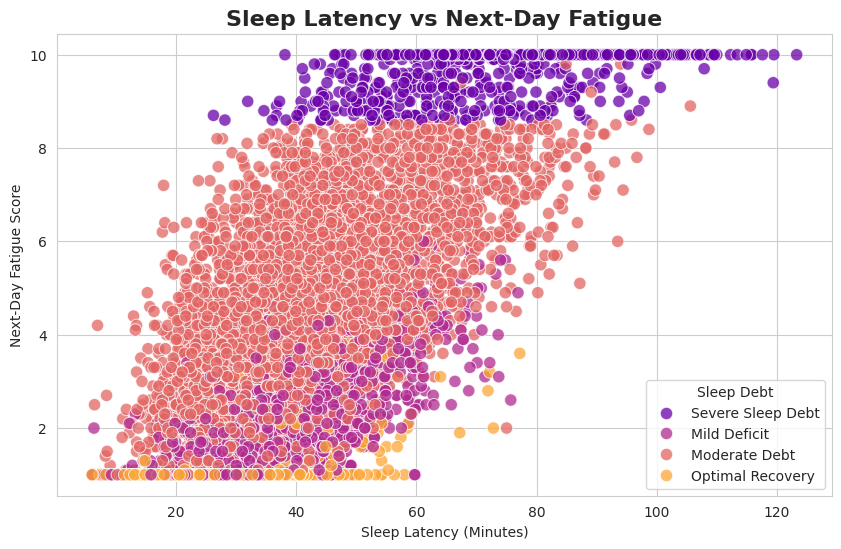

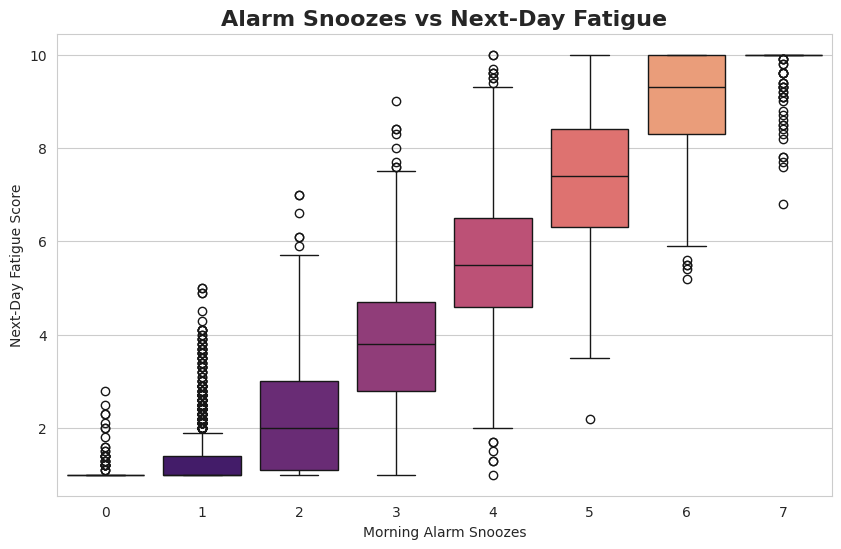

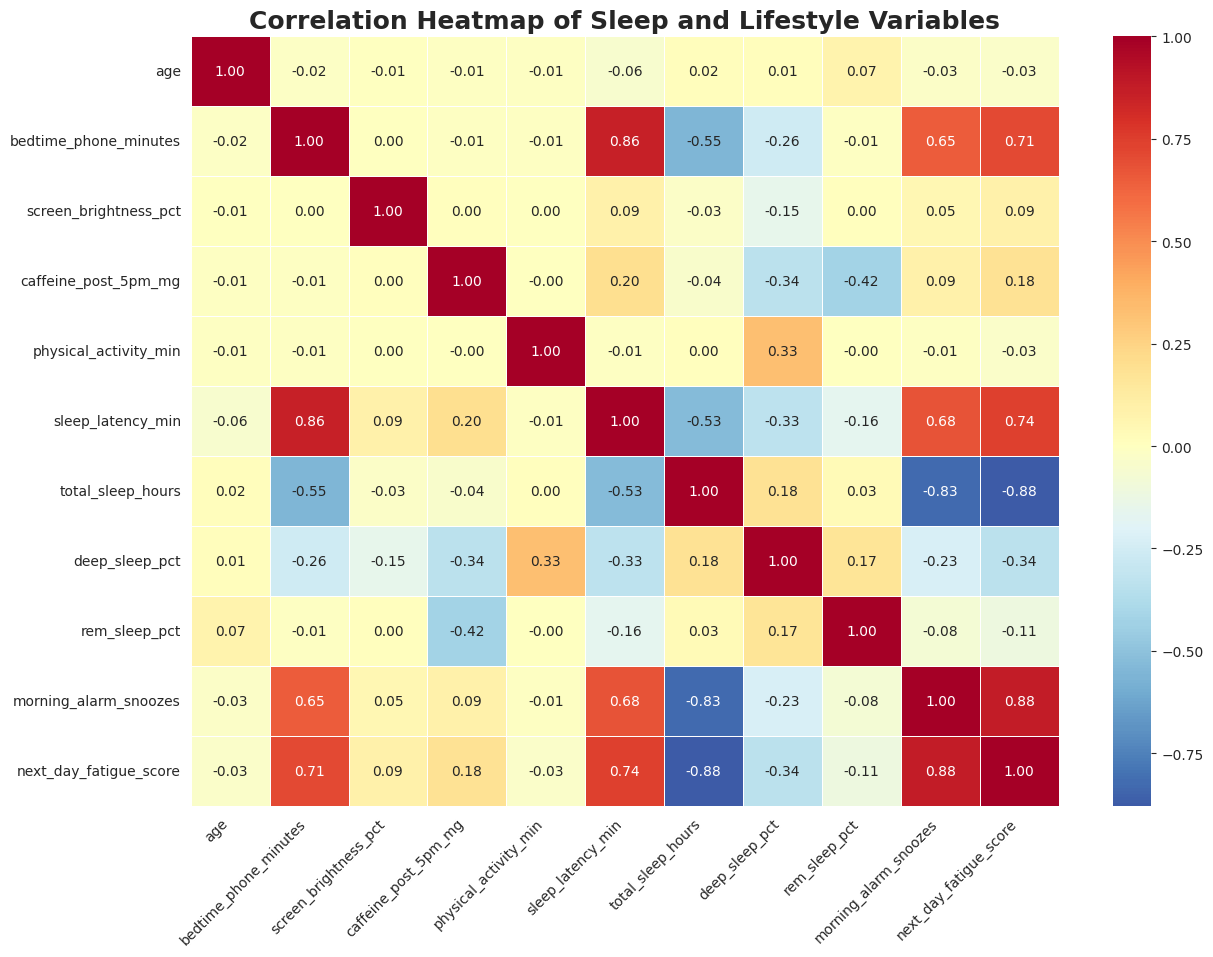

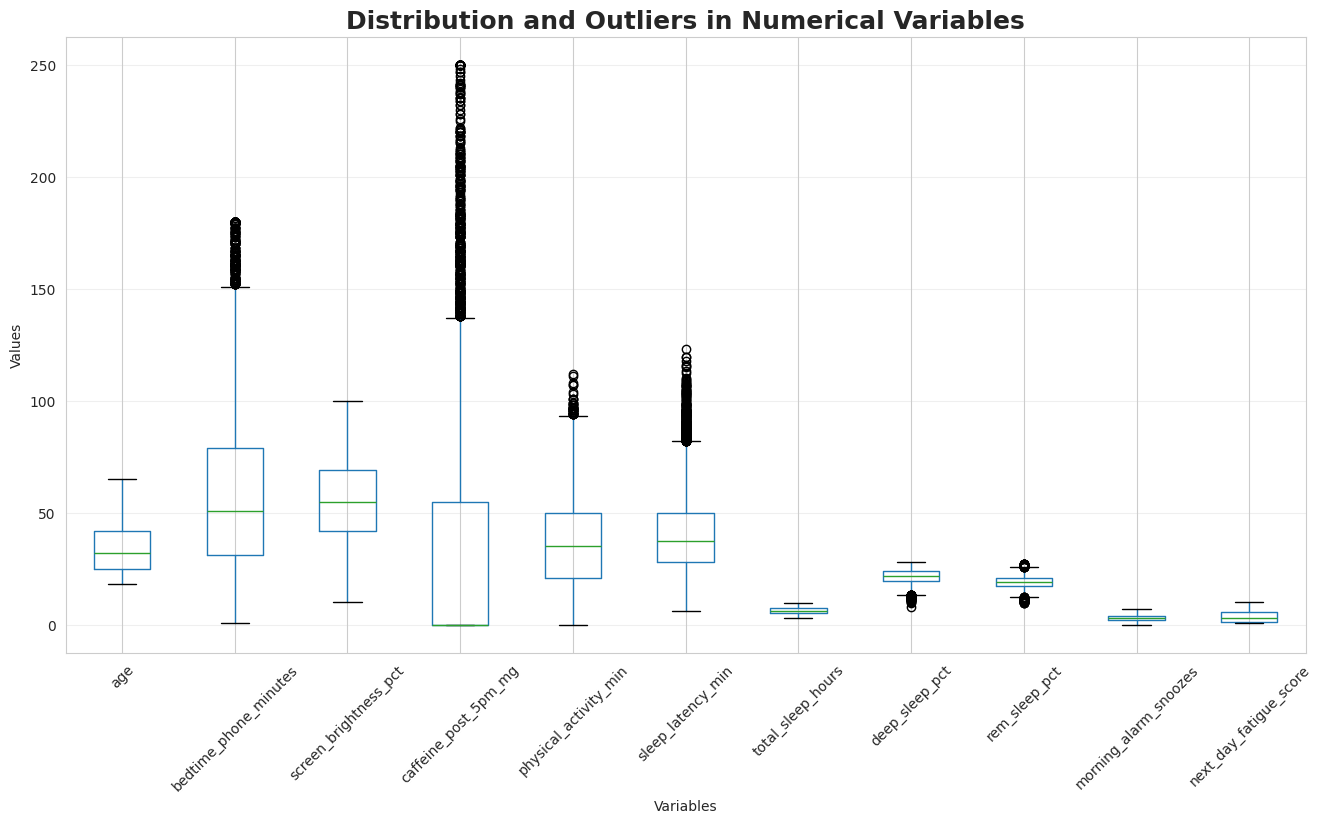

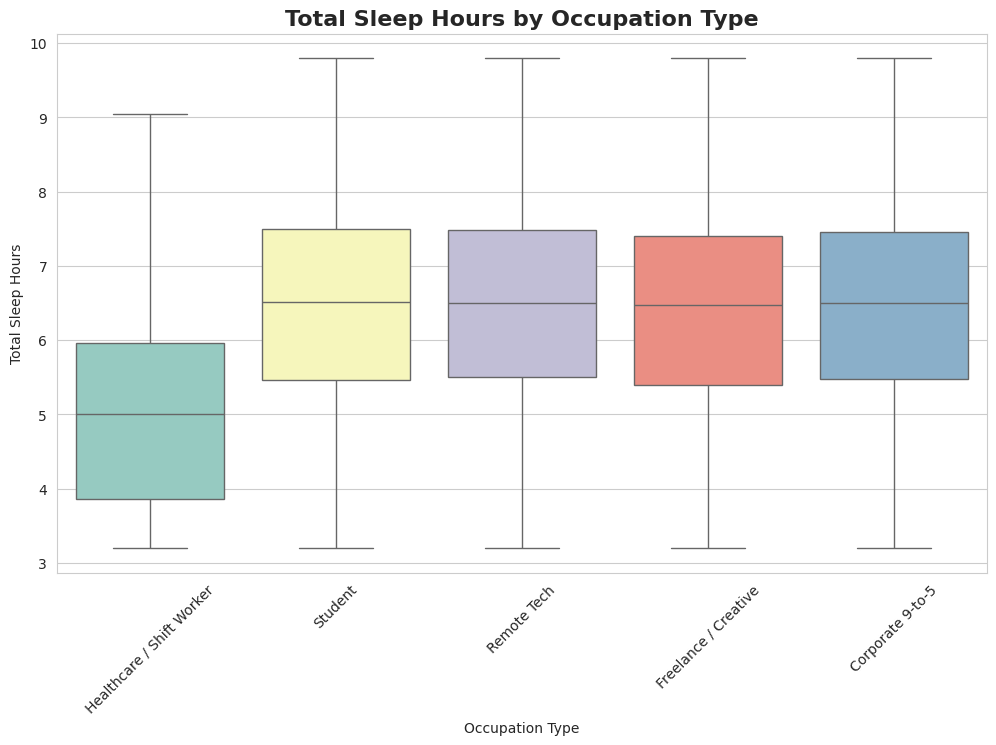

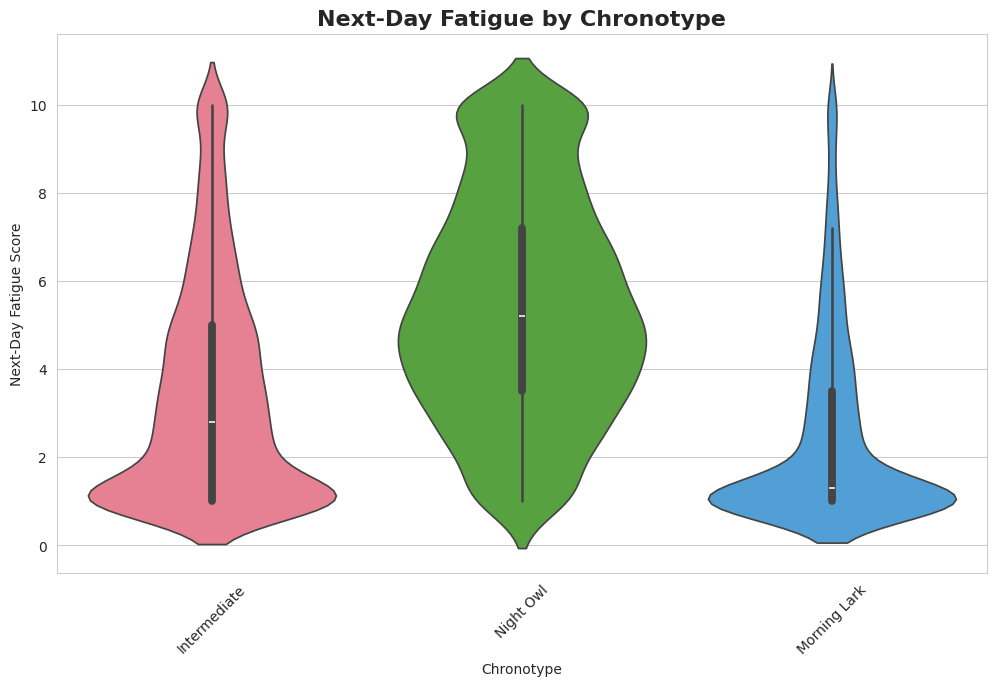

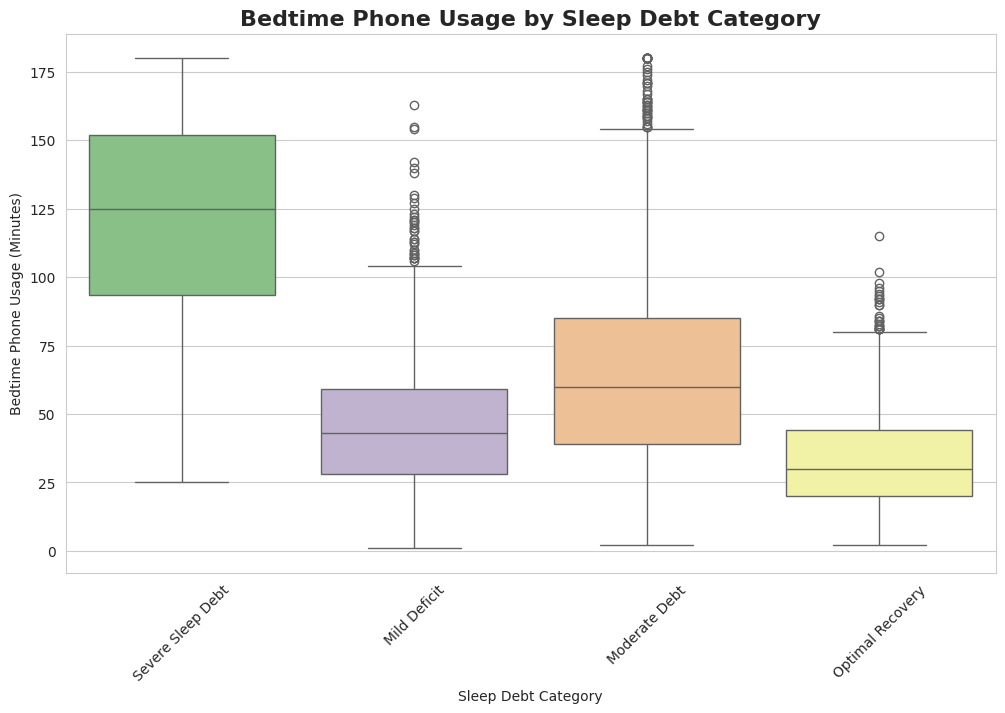

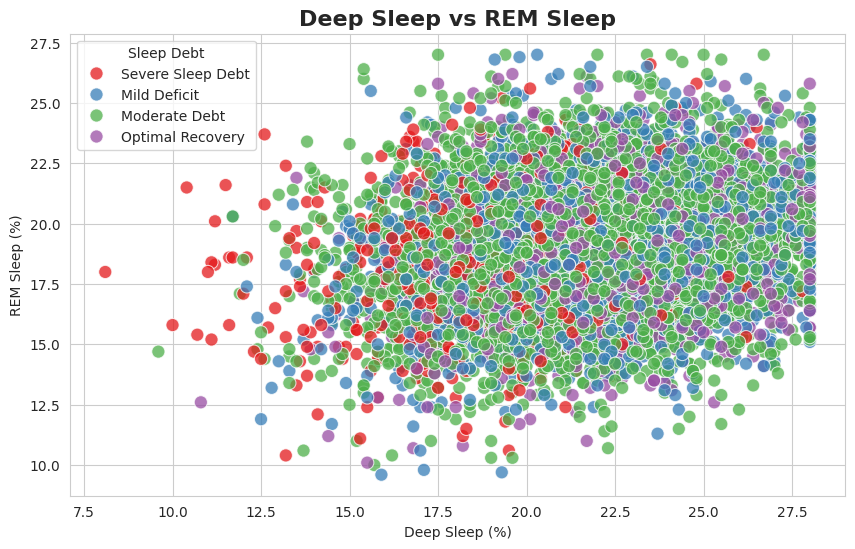


NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,8500.0,34.355647,11.584259,18.0,25.00,32.00,42.00,65.0
bedtime_phone_minutes,8500.0,59.250000,36.931991,1.0,31.00,51.00,79.00,180.0
screen_brightness_pct,8500.0,55.153882,19.850550,10.0,42.00,55.00,69.00,100.0
caffeine_post_5pm_mg,8500.0,33.222471,51.935645,0.0,0.00,0.00,55.00,250.0
physical_activity_min,8500.0,35.701412,20.819390,0.0,21.00,35.00,50.00,112.0
sleep_latency_min,8500.0,40.671471,17.444914,6.0,28.20,37.60,49.70,123.3
total_sleep_hours,8500.0,6.266209,1.446258,3.2,5.24,6.33,7.35,9.8
deep_sleep_pct,8500.0,21.735741,3.069377,8.1,19.70,21.90,23.90,28.0
rem_sleep_pct,8500.0,19.105859,2.546459,9.6,17.40,19.10,20.80,27.0
morning_alarm_snoozes,8500.0,2.766000,1.695407,0.0,2.00,3.00,4.00,7.0



CATEGORICAL SUMMARY

--- gender ---
gender
Female        4347
Male          3905
Non-Binary     248
Name: count, dtype: int64

--- occupation_type ---
occupation_type
Corporate 9-to-5             2838
Remote Tech                  2142
Student                      1622
Healthcare / Shift Worker     997
Freelance / Creative          901
Name: count, dtype: int64

--- chronotype ---
chronotype
Intermediate    3880
Night Owl       2455
Morning Lark    2165
Name: count, dtype: int64

--- primary_bedtime_app ---
primary_bedtime_app
TikTok / Reels              2198
YouTube                     1928
Instagram / Reddit          1630
Streaming (Netflix/Hulu)    1301
Messaging / Chat             847
News / Reading               596
Name: count, dtype: int64

--- blue_light_filter_active ---
blue_light_filter_active
0    4524
1    3976
Name: count, dtype: int64

--- sleep_debt_category ---
sleep_debt_category
Moderate Debt        4462
Mild Deficit         2004
Optimal Recovery     1387
Severe Slee

In [13]:
sns.set_style("whitegrid")

# ============================================================
# 3. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Age Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 4. GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

gender_counts = df["gender"].value_counts()

plt.bar(
    gender_counts.index,
    gender_counts.values,
    color=["tomato", "royalblue", "mediumseagreen", "orange"]
)

plt.title("Gender Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 5. OCCUPATION TYPE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

occupation_counts = df["occupation_type"].value_counts()

sns.barplot(
    x=occupation_counts.index,
    y=occupation_counts.values,
    palette="Set2"
)

plt.title("Users by Occupation Type", fontsize=16, fontweight="bold")
plt.xlabel("Occupation Type")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 6. CHRONOTYPE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

chronotype_counts = df["chronotype"].value_counts()

plt.bar(
    chronotype_counts.index,
    chronotype_counts.values,
    color=["purple", "teal", "gold", "coral", "steelblue"]
)

plt.title("Chronotype Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Chronotype")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 7. PRIMARY BEDTIME APP DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

app_counts = df["primary_bedtime_app"].value_counts().head(10)

sns.barplot(
    x=app_counts.index,
    y=app_counts.values,
    palette="husl"
)

plt.title("Top Bedtime Apps Used", fontsize=16, fontweight="bold")
plt.xlabel("Primary Bedtime App")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 8. BEDTIME PHONE USAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="bedtime_phone_minutes",
    bins=25,
    kde=True,
    color="darkorange"
)

plt.title("Bedtime Phone Usage Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Phone Usage Before Bed (Minutes)")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 9. SCREEN BRIGHTNESS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="screen_brightness_pct",
    bins=20,
    kde=True,
    color="mediumorchid"
)

plt.title("Screen Brightness Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Screen Brightness (%)")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 10. BLUE LIGHT FILTER ACTIVE
# ============================================================

plt.figure(figsize=(8, 6))

blue_counts = df["blue_light_filter_active"].value_counts()

plt.pie(
    blue_counts.values,
    labels=blue_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue", "salmon"]
)

plt.title("Blue Light Filter Usage", fontsize=16, fontweight="bold")
plt.show()


# ============================================================
# 11. CAFFEINE AFTER 5 PM
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="caffeine_post_5pm_mg",
    bins=25,
    kde=True,
    color="brown"
)

plt.title("Caffeine Consumption After 5 PM", fontsize=16, fontweight="bold")
plt.xlabel("Caffeine After 5 PM (mg)")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 12. PHYSICAL ACTIVITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="physical_activity_min",
    bins=25,
    kde=True,
    color="forestgreen"
)

plt.title("Physical Activity Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Physical Activity (Minutes)")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 13. SLEEP LATENCY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="sleep_latency_min",
    bins=25,
    kde=True,
    color="crimson"
)

plt.title("Sleep Latency Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Sleep Latency (Minutes)")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 14. TOTAL SLEEP HOURS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="total_sleep_hours",
    bins=20,
    kde=True,
    color="dodgerblue"
)

plt.title("Total Sleep Hours Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Total Sleep Hours")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 15. DEEP SLEEP PERCENTAGE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="deep_sleep_pct",
    bins=20,
    kde=True,
    color="darkviolet"
)

plt.title("Deep Sleep Percentage Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Deep Sleep (%)")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 16. REM SLEEP PERCENTAGE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="rem_sleep_pct",
    bins=20,
    kde=True,
    color="teal"
)

plt.title("REM Sleep Percentage Distribution", fontsize=16, fontweight="bold")
plt.xlabel("REM Sleep (%)")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 17. MORNING ALARM SNOOZES
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="morning_alarm_snoozes",
    palette="Spectral"
)

plt.title("Morning Alarm Snoozes", fontsize=16, fontweight="bold")
plt.xlabel("Number of Snoozes")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 18. NEXT DAY FATIGUE SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="next_day_fatigue_score",
    bins=20,
    kde=True,
    color="firebrick"
)

plt.title("Next-Day Fatigue Score Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Fatigue Score")
plt.ylabel("Number of Users")
plt.show()


# ============================================================
# 19. SLEEP DEBT CATEGORY
# ============================================================

plt.figure(figsize=(10, 6))

sleep_debt_counts = df["sleep_debt_category"].value_counts()

sns.barplot(
    x=sleep_debt_counts.index,
    y=sleep_debt_counts.values,
    palette="viridis"
)

plt.title("Sleep Debt Category Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Sleep Debt Category")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 20. TOTAL SLEEP HOURS BY GENDER
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="gender",
    y="total_sleep_hours",
    palette="Set1"
)

plt.title("Total Sleep Hours by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Total Sleep Hours")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 21. TOTAL SLEEP HOURS BY CHRONOTYPE
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="chronotype",
    y="total_sleep_hours",
    palette="Set2"
)

plt.title("Total Sleep Hours by Chronotype", fontsize=16, fontweight="bold")
plt.xlabel("Chronotype")
plt.ylabel("Total Sleep Hours")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 22. FATIGUE SCORE BY SLEEP DEBT CATEGORY
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="sleep_debt_category",
    y="next_day_fatigue_score",
    palette="coolwarm"
)

plt.title(
    "Next-Day Fatigue Score by Sleep Debt Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sleep Debt Category")
plt.ylabel("Next-Day Fatigue Score")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 23. PHONE USAGE vs TOTAL SLEEP HOURS
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="bedtime_phone_minutes",
    y="total_sleep_hours",
    hue="gender",
    palette="Set1",
    s=80,
    alpha=0.75
)

plt.title(
    "Bedtime Phone Usage vs Total Sleep Hours",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Phone Usage Before Bed (Minutes)")
plt.ylabel("Total Sleep Hours")
plt.legend(title="Gender")
plt.show()


# ============================================================
# 24. PHONE USAGE vs FATIGUE SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="bedtime_phone_minutes",
    y="next_day_fatigue_score",
    hue="sleep_debt_category",
    palette="viridis",
    s=80,
    alpha=0.75
)

plt.title(
    "Bedtime Phone Usage vs Next-Day Fatigue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Phone Usage Before Bed (Minutes)")
plt.ylabel("Next-Day Fatigue Score")
plt.legend(title="Sleep Debt")
plt.show()


# ============================================================
# 25. CAFFEINE vs SLEEP HOURS
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="caffeine_post_5pm_mg",
    y="total_sleep_hours",
    hue="chronotype",
    palette="tab10",
    s=80,
    alpha=0.75
)

plt.title(
    "Evening Caffeine vs Total Sleep Hours",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Caffeine After 5 PM (mg)")
plt.ylabel("Total Sleep Hours")
plt.legend(title="Chronotype")
plt.show()


# ============================================================
# 26. PHYSICAL ACTIVITY vs SLEEP HOURS
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="physical_activity_min",
    y="total_sleep_hours",
    hue="gender",
    palette="Dark2",
    s=80,
    alpha=0.75
)

plt.title(
    "Physical Activity vs Total Sleep Hours",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Physical Activity (Minutes)")
plt.ylabel("Total Sleep Hours")
plt.legend(title="Gender")
plt.show()


# ============================================================
# 27. SLEEP LATENCY vs FATIGUE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="sleep_latency_min",
    y="next_day_fatigue_score",
    hue="sleep_debt_category",
    palette="plasma",
    s=80,
    alpha=0.75
)

plt.title(
    "Sleep Latency vs Next-Day Fatigue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sleep Latency (Minutes)")
plt.ylabel("Next-Day Fatigue Score")
plt.legend(title="Sleep Debt")
plt.show()


# ============================================================
# 28. ALARM SNOOZES vs FATIGUE
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="morning_alarm_snoozes",
    y="next_day_fatigue_score",
    palette="magma"
)

plt.title(
    "Alarm Snoozes vs Next-Day Fatigue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Morning Alarm Snoozes")
plt.ylabel("Next-Day Fatigue Score")
plt.show()


# ============================================================
# 29. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "age",
    "bedtime_phone_minutes",
    "screen_brightness_pct",
    "caffeine_post_5pm_mg",
    "physical_activity_min",
    "sleep_latency_min",
    "total_sleep_hours",
    "deep_sleep_pct",
    "rem_sleep_pct",
    "morning_alarm_snoozes",
    "next_day_fatigue_score"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    center=0
)

plt.title(
    "Correlation Heatmap of Sleep and Lifestyle Variables",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


# ============================================================
# 30. NUMERICAL VARIABLES - BOXPLOTS
# ============================================================

plt.figure(figsize=(16, 8))

df[numeric_columns].boxplot(
    rot=45
)

plt.title(
    "Distribution and Outliers in Numerical Variables",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Variables")
plt.ylabel("Values")
plt.grid(axis="y", alpha=0.3)
plt.show()


# ============================================================
# 31. SLEEP HOURS BY OCCUPATION
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="occupation_type",
    y="total_sleep_hours",
    palette="Set3"
)

plt.title(
    "Total Sleep Hours by Occupation Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Occupation Type")
plt.ylabel("Total Sleep Hours")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 32. FATIGUE BY CHRONOTYPE
# ============================================================

plt.figure(figsize=(12, 7))

sns.violinplot(
    data=df,
    x="chronotype",
    y="next_day_fatigue_score",
    palette="husl"
)

plt.title(
    "Next-Day Fatigue by Chronotype",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Chronotype")
plt.ylabel("Next-Day Fatigue Score")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 33. SLEEP DEBT vs PHONE USAGE
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="sleep_debt_category",
    y="bedtime_phone_minutes",
    palette="Accent"
)

plt.title(
    "Bedtime Phone Usage by Sleep Debt Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sleep Debt Category")
plt.ylabel("Bedtime Phone Usage (Minutes)")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 34. DEEP SLEEP vs REM SLEEP
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="deep_sleep_pct",
    y="rem_sleep_pct",
    hue="sleep_debt_category",
    palette="Set1",
    s=90,
    alpha=0.75
)

plt.title(
    "Deep Sleep vs REM Sleep",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Deep Sleep (%)")
plt.ylabel("REM Sleep (%)")
plt.legend(title="Sleep Debt")
plt.show()


# ============================================================
# 35. SUMMARY STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("NUMERICAL SUMMARY")
print("=" * 60)

display(
    df[numeric_columns].describe().T
)


print("\n" + "=" * 60)
print("CATEGORICAL SUMMARY")
print("=" * 60)

categorical_columns = [
    "gender",
    "occupation_type",
    "chronotype",
    "primary_bedtime_app",
    "blue_light_filter_active",
    "sleep_debt_category"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())

## Feature engineering

Dataset Shape: (8500, 18)

Columns:
['user_id', 'age', 'gender', 'occupation_type', 'chronotype', 'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct', 'blue_light_filter_active', 'caffeine_post_5pm_mg', 'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours', 'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes', 'next_day_fatigue_score', 'sleep_debt_category']

Missing Values:
user_id                     0
age                         0
gender                      0
occupation_type             0
chronotype                  0
bedtime_phone_minutes       0
primary_bedtime_app         0
screen_brightness_pct       0
blue_light_filter_active    0
caffeine_post_5pm_mg        0
physical_activity_min       0
sleep_latency_min           0
total_sleep_hours           0
deep_sleep_pct              0
rem_sleep_pct               0
morning_alarm_snoozes       0
next_day_fatigue_score      0
sleep_debt_category         0
dtype: int64

Shape after removing user_id: 

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,100.00%,100.00%,100.00%,100.00%,1.0000
1,Gradient Boosting,100.00%,100.00%,100.00%,100.00%,1.0000
2,Random Forest,99.82%,99.83%,99.82%,99.82%,1.0000
3,XGBoost,99.53%,99.53%,99.53%,99.53%,1.0000
4,Logistic Regression,98.76%,98.76%,98.76%,98.76%,0.9995
5,KNN,79.71%,80.19%,79.71%,79.72%,0.9387


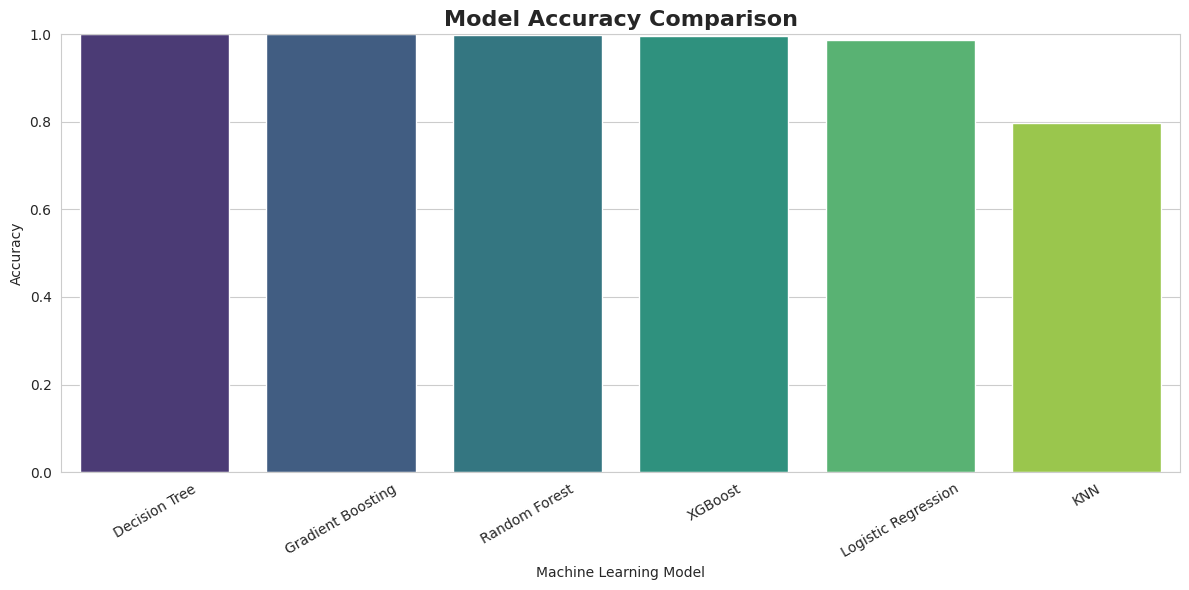

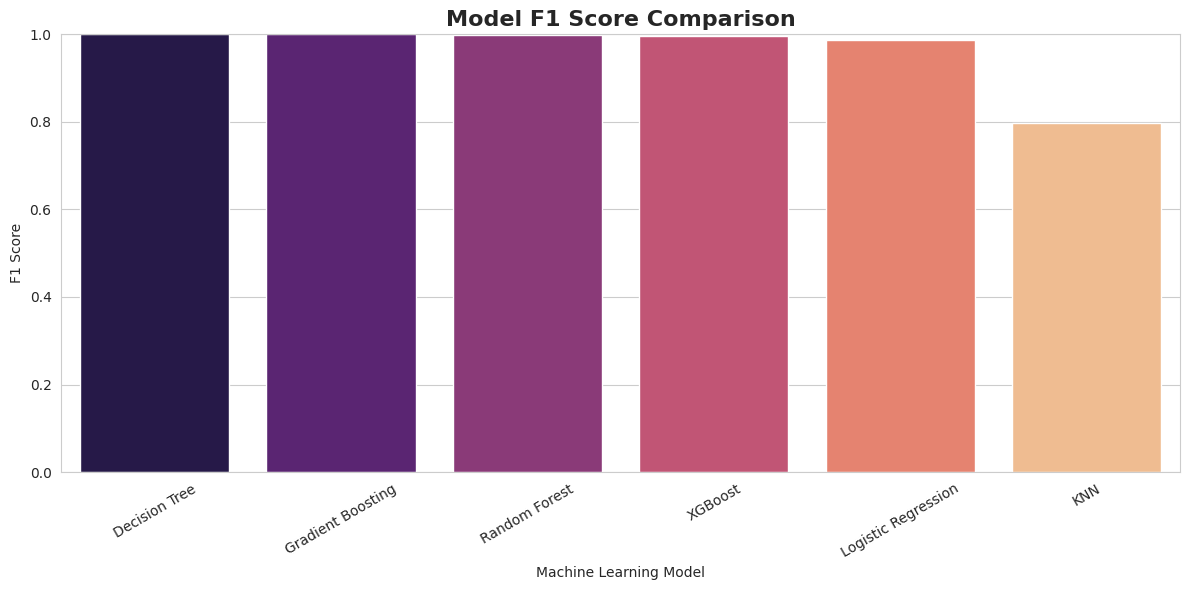

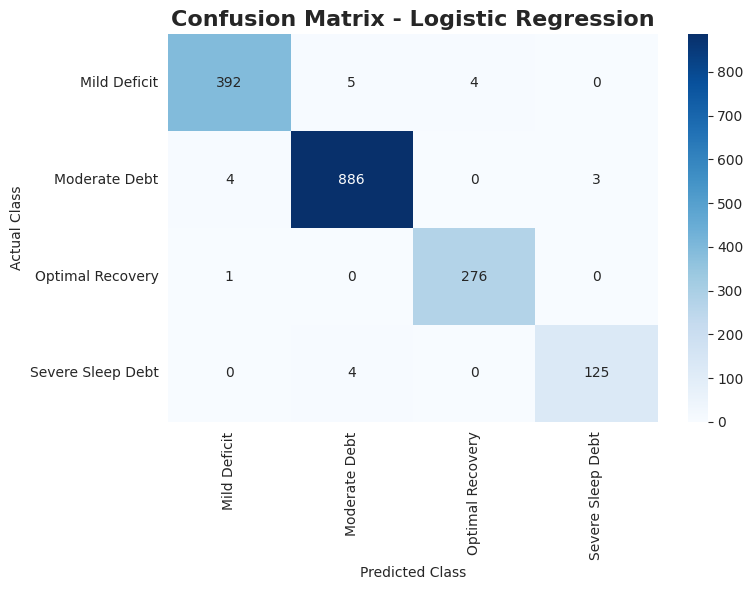

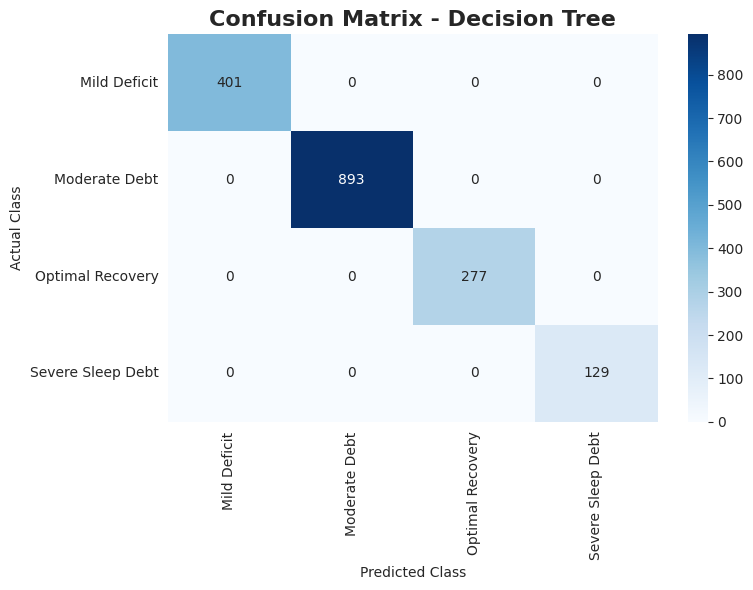

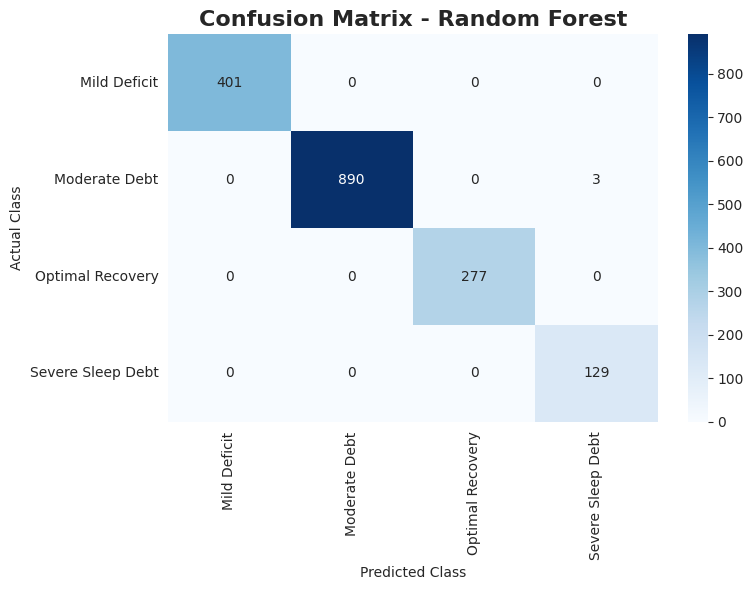

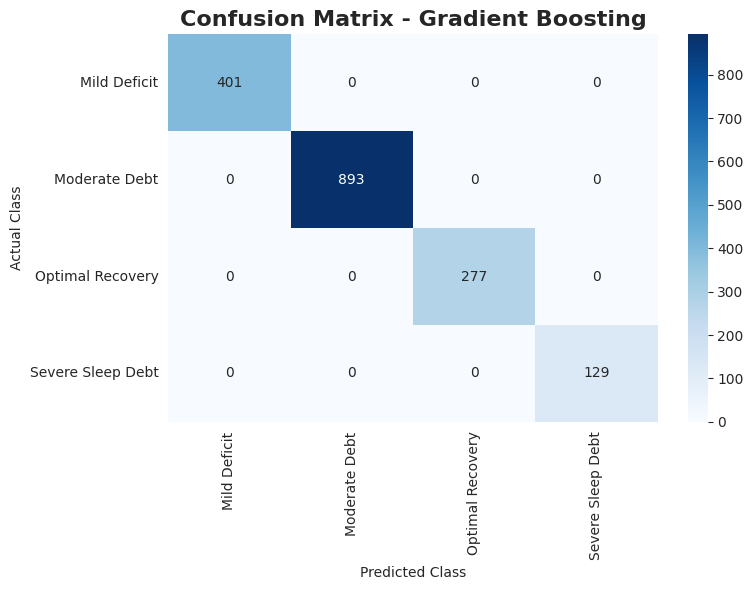

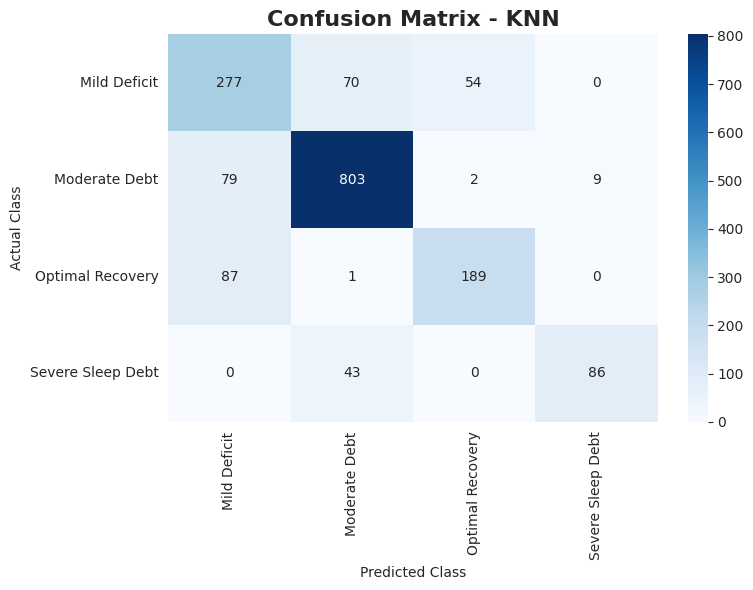

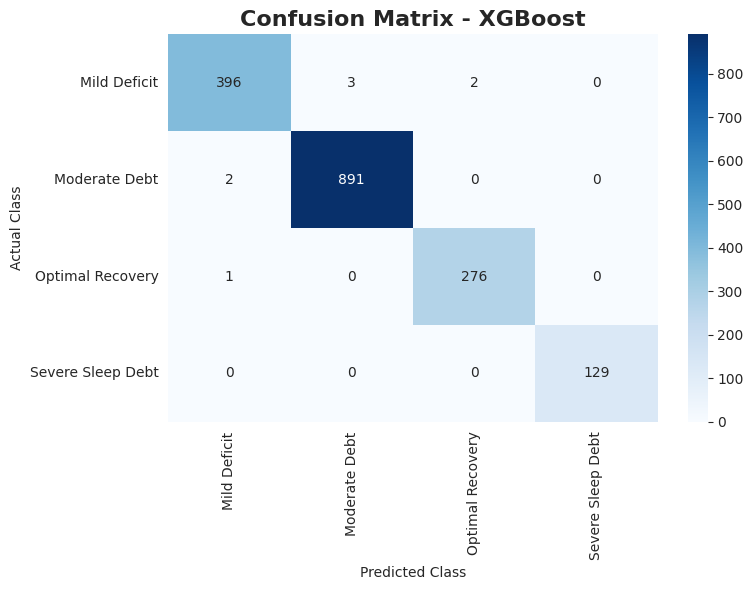


CLASSIFICATION REPORT: Logistic Regression
                   precision    recall  f1-score   support

     Mild Deficit       0.99      0.98      0.98       401
    Moderate Debt       0.99      0.99      0.99       893
 Optimal Recovery       0.99      1.00      0.99       277
Severe Sleep Debt       0.98      0.97      0.97       129

         accuracy                           0.99      1700
        macro avg       0.98      0.98      0.98      1700
     weighted avg       0.99      0.99      0.99      1700


CLASSIFICATION REPORT: Decision Tree
                   precision    recall  f1-score   support

     Mild Deficit       1.00      1.00      1.00       401
    Moderate Debt       1.00      1.00      1.00       893
 Optimal Recovery       1.00      1.00      1.00       277
Severe Sleep Debt       1.00      1.00      1.00       129

         accuracy                           1.00      1700
        macro avg       1.00      1.00      1.00      1700
     weighted avg       1.00

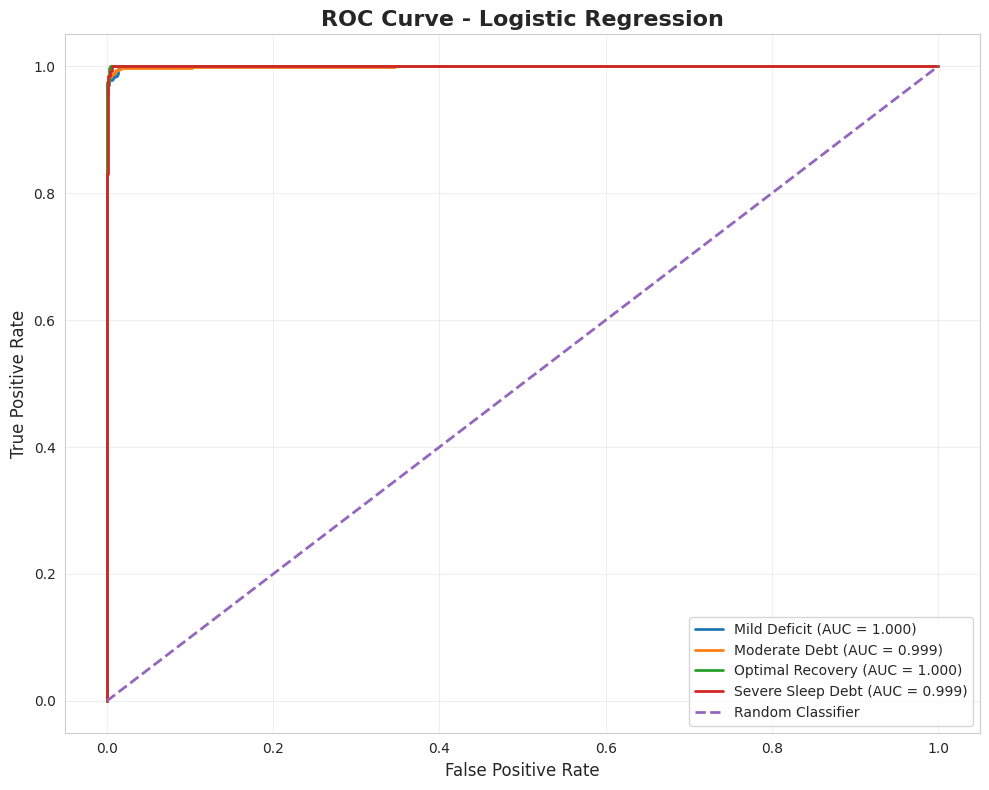

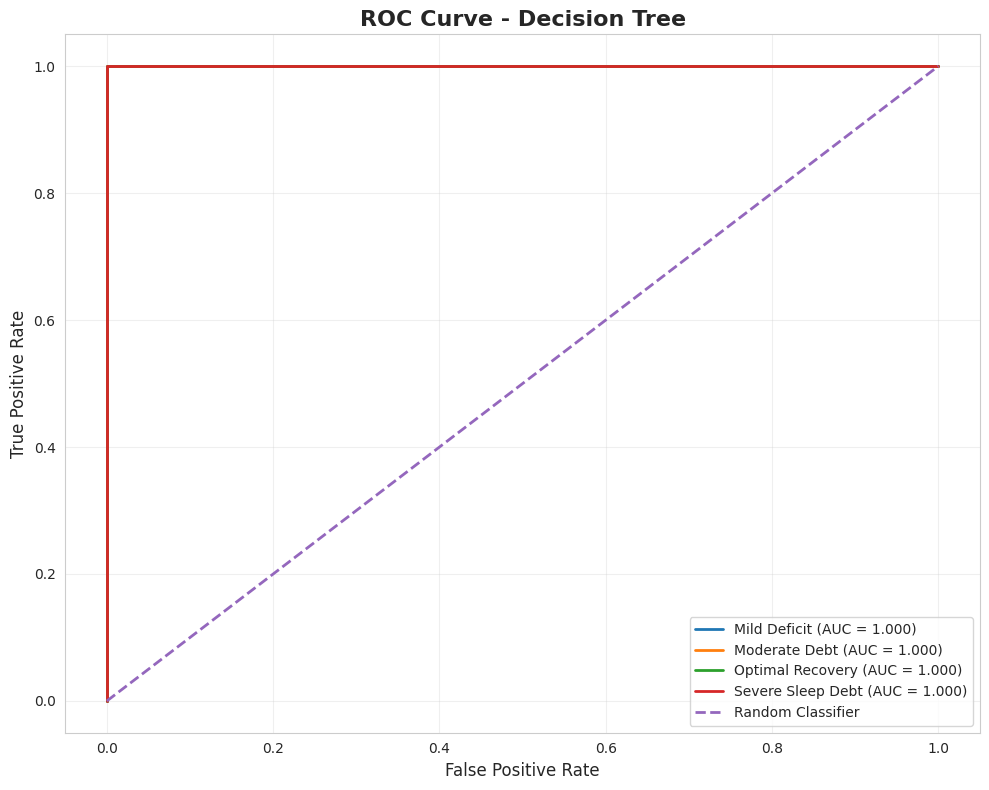

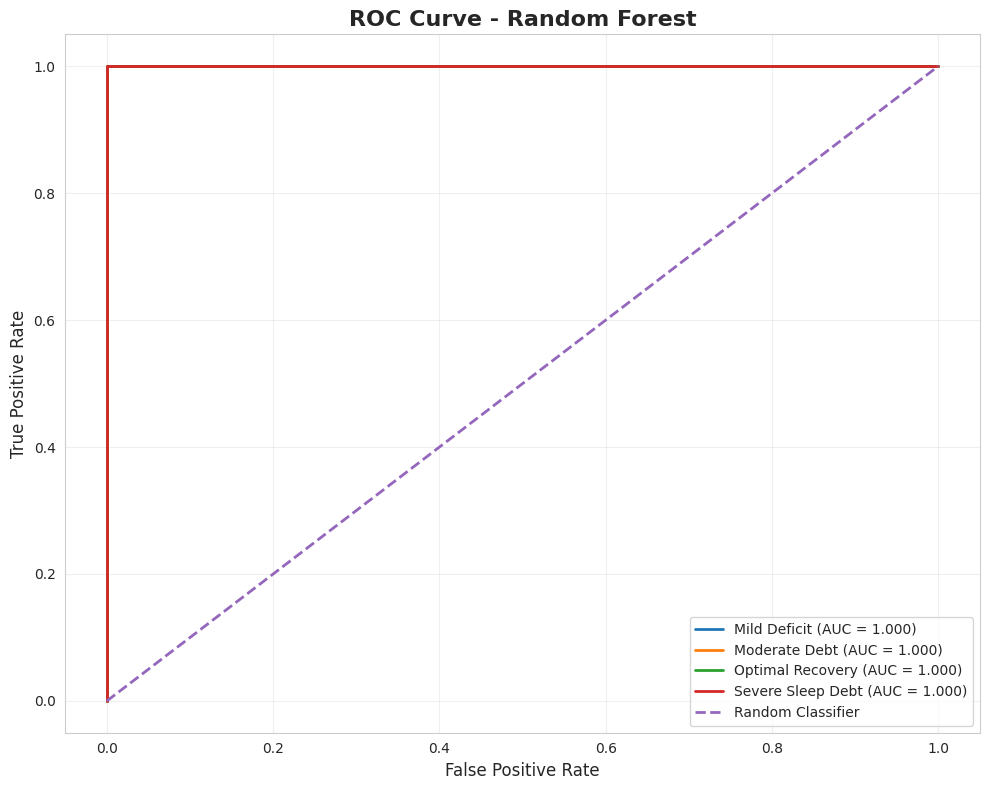

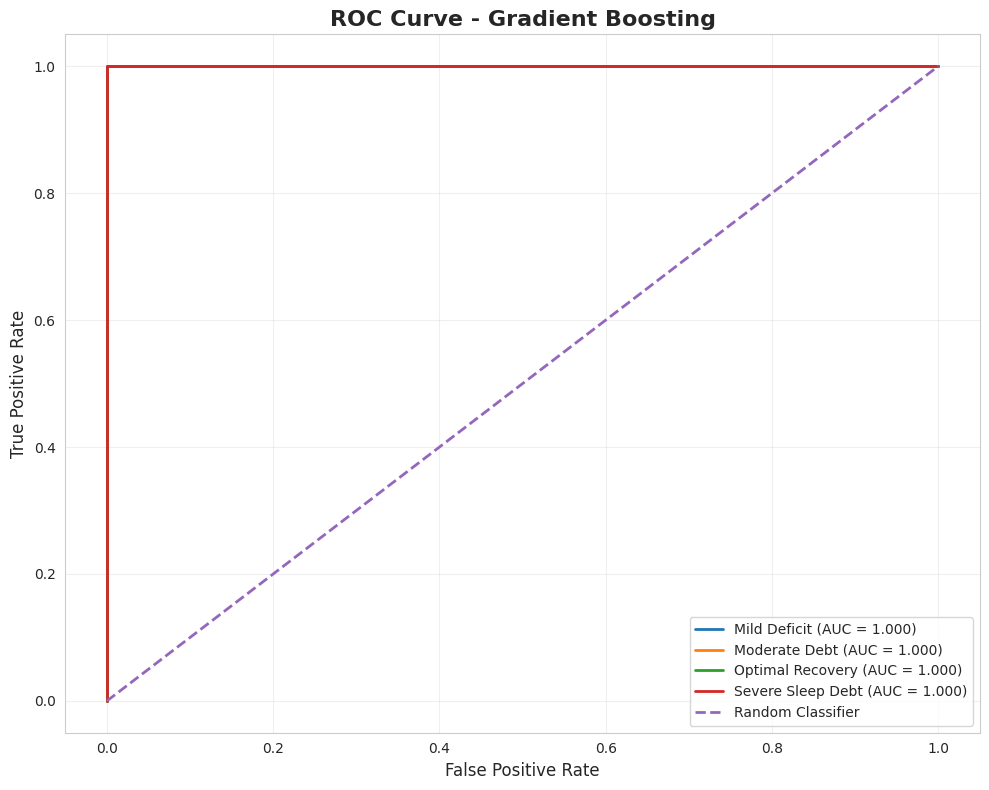

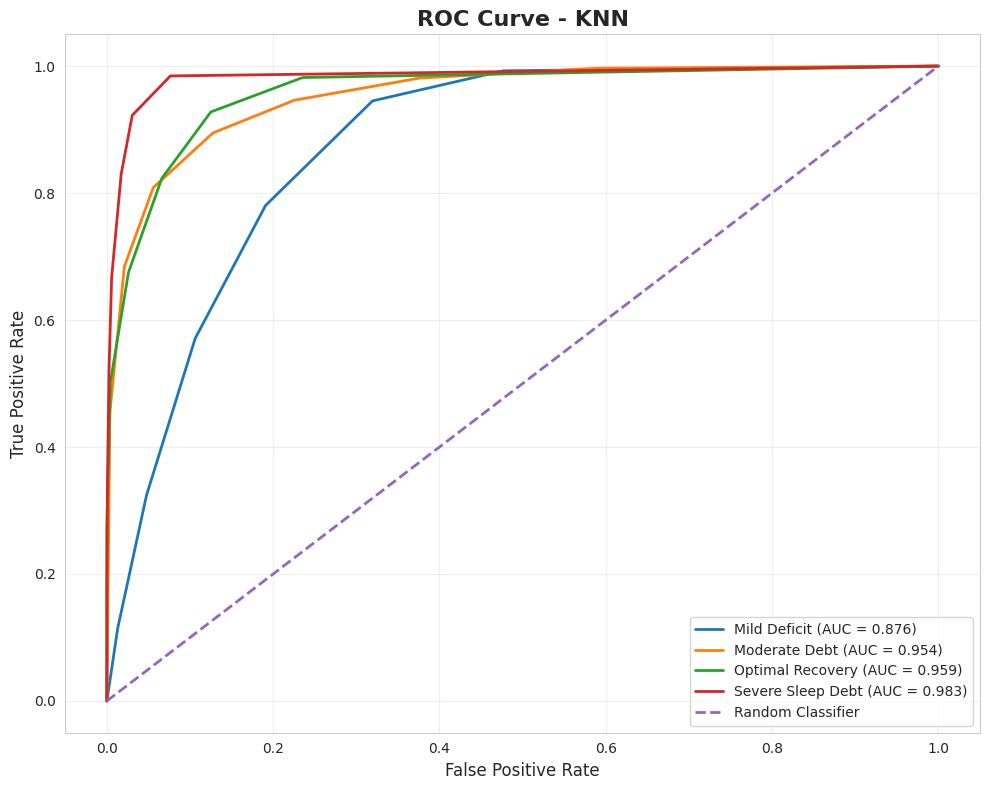

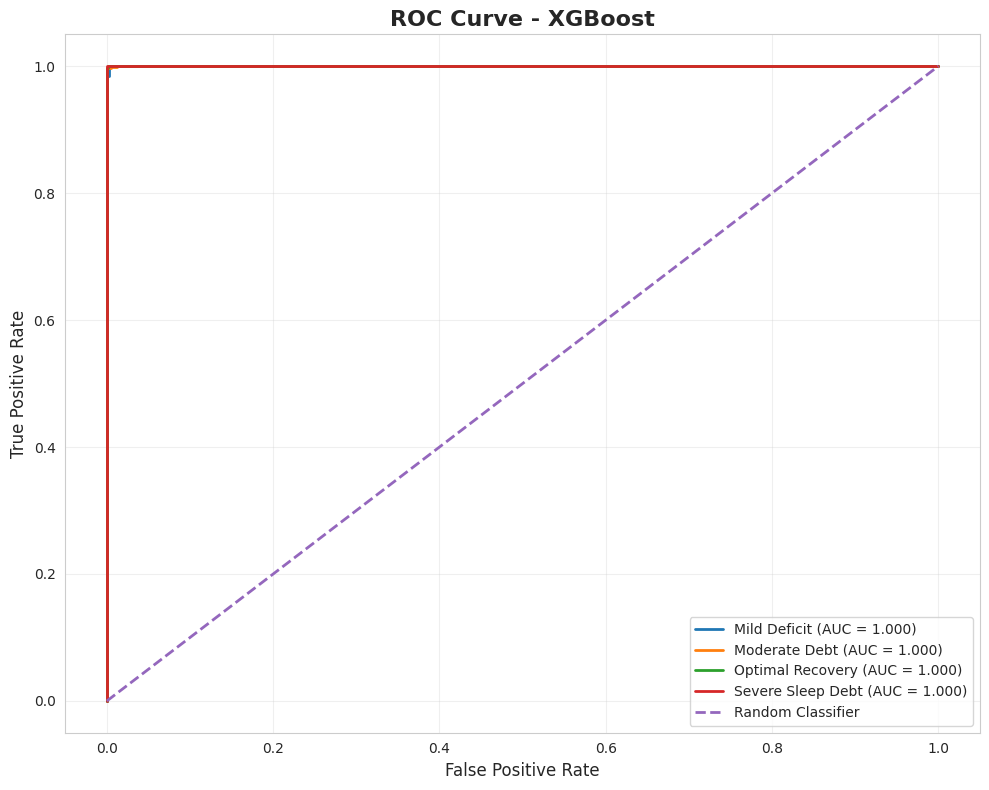

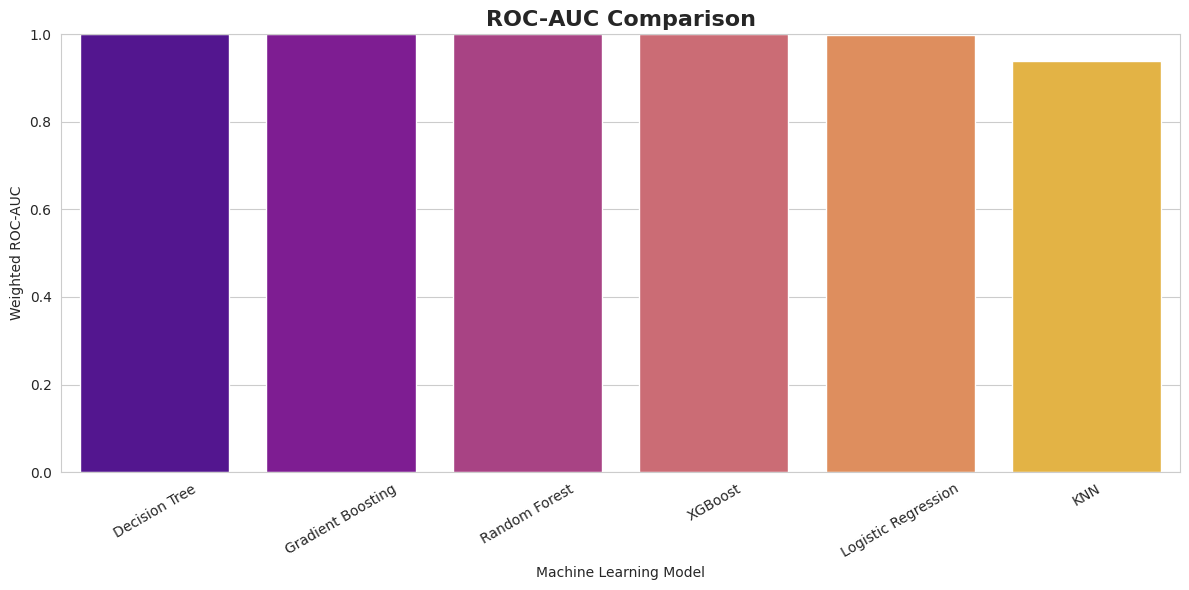


RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
11,total_sleep_hours,0.561101
15,next_day_fatigue_score,0.226771
14,morning_alarm_snoozes,0.079358
3,chronotype,0.039937
10,sleep_latency_min,0.030393
4,bedtime_phone_minutes,0.023732
12,deep_sleep_pct,0.007925
8,caffeine_post_5pm_mg,0.005617
6,screen_brightness_pct,0.005017
13,rem_sleep_pct,0.005001


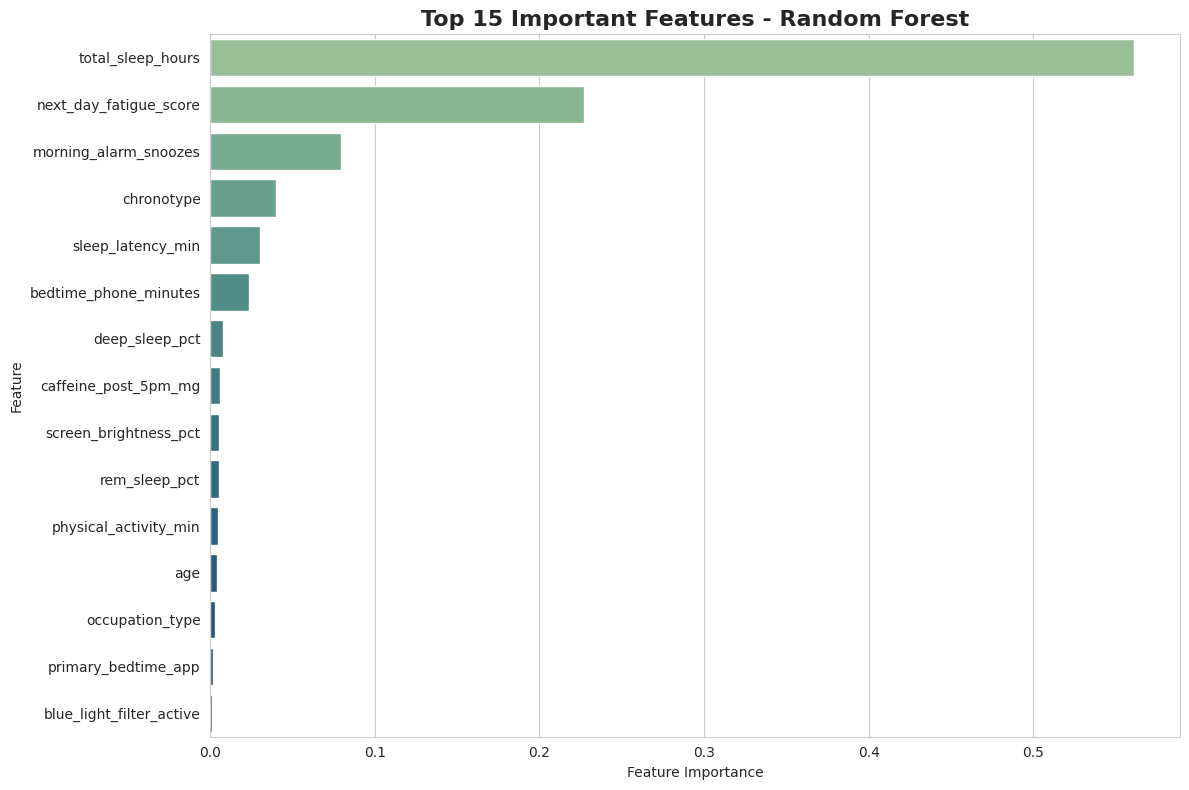


SAMPLE PREDICTIONS
Actual: Mild Deficit | Predicted: Mild Deficit
Actual: Moderate Debt | Predicted: Moderate Debt
Actual: Optimal Recovery | Predicted: Optimal Recovery
Actual: Mild Deficit | Predicted: Mild Deficit
Actual: Severe Sleep Debt | Predicted: Severe Sleep Debt
Actual: Mild Deficit | Predicted: Mild Deficit
Actual: Moderate Debt | Predicted: Moderate Debt
Actual: Mild Deficit | Predicted: Mild Deficit
Actual: Moderate Debt | Predicted: Moderate Debt
Actual: Moderate Debt | Predicted: Moderate Debt


In [14]:

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost is not installed. Skipping XGBoost.")


# ============================================================
# 2. CHECK DATASET
# ============================================================

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 3. REMOVE ID COLUMN
# ============================================================

# user_id is an identifier and should not be used as a
# predictive feature.

data = df.copy()

if "user_id" in data.columns:
    data = data.drop("user_id", axis=1)

print("\nShape after removing user_id:", data.shape)


# ============================================================
# 4. DEFINE TARGET VARIABLE
# ============================================================

target = "sleep_debt_category"

if target not in data.columns:
    raise ValueError(
        f"Target column '{target}' was not found in the dataset."
    )

X = data.drop(target, axis=1)
y = data[target]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Classes:")
print(y.value_counts())


# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

# Separate numerical and categorical columns

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numeric_columns)


# Fill numerical missing values using median
for column in numeric_columns:
    X[column] = X[column].fillna(X[column].median())


# Fill categorical missing values using mode
for column in categorical_columns:

    if X[column].isnull().any():

        mode_value = X[column].mode()

        if len(mode_value) > 0:
            X[column] = X[column].fillna(mode_value.iloc[0])
        else:
            X[column] = X[column].fillna("Unknown")


# Fill missing target values
valid_target = y.notna()

X = X.loc[valid_target].copy()
y = y.loc[valid_target].copy()


# ============================================================
# 6. LABEL ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print("\nTarget Encoding:")
for number, category in enumerate(target_encoder.classes_):
    print(number, "=", category)

print("\nEncoded Target:")
print(np.unique(y_encoded))


# ============================================================
# 7. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Target Distribution:")
print(pd.Series(y_test).value_counts())


# ============================================================
# 8. LABEL ENCODE CATEGORICAL FEATURES
# ============================================================

# We fit encoders ONLY on the training data.
# This prevents test-data leakage.

feature_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    # Convert to string
    train_values = X_train[column].astype(str)
    test_values = X_test[column].astype(str)

    # Handle categories that might only appear in test data
    known_values = set(train_values.unique())

    test_values = test_values.apply(
        lambda value: value if value in known_values else "Unknown"
    )

    # Add Unknown to training data if required
    if "Unknown" in test_values.values and "Unknown" not in known_values:
        train_values = pd.concat(
            [train_values, pd.Series(["Unknown"])],
            ignore_index=True
        )

    encoder.fit(train_values)

    X_train[column] = encoder.transform(
        X_train[column].astype(str)
    )

    X_test[column] = encoder.transform(
        test_values
    )

    feature_encoders[column] = encoder


# ============================================================
# 9. CONVERT BOOLEAN COLUMNS
# ============================================================

for column in X_train.columns:

    if X_train[column].dtype == bool:
        X_train[column] = X_train[column].astype(int)
        X_test[column] = X_test[column].astype(int)


# ============================================================
# 10. CONVERT DATA TO NUMERIC
# ============================================================

X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")


# Handle any new missing values
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())


# ============================================================
# 11. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print("\nScaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)


# ============================================================
# 12. CREATE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    )
}


# ============================================================
# 13. ADD XGBOOST IF AVAILABLE
# ============================================================

if xgb_available:

    number_of_classes = len(np.unique(y_encoded))

    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=number_of_classes,
        eval_metric="mlogloss",
        random_state=42
    )


# ============================================================
# 14. TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

predictions = {}

probabilities = {}


for model_name, model in models.items():

    print("\n" + "=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)

    # Train
    model.fit(
        X_train_scaled,
        y_train
    )

    # Prediction
    y_pred = model.predict(
        X_test_scaled
    )

    # Probability
    if hasattr(model, "predict_proba"):

        y_probability = model.predict_proba(
            X_test_scaled
        )

    else:

        y_probability = None


    # Store
    trained_models[model_name] = model
    predictions[model_name] = y_pred
    probabilities[model_name] = y_probability


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    # ROC-AUC
    if y_probability is not None:

        try:

            roc_auc = roc_auc_score(
                y_test,
                y_probability,
                multi_class="ovr",
                average="weighted"
            )

        except ValueError:

            roc_auc = np.nan

    else:

        roc_auc = np.nan


    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })


    # --------------------------------------------------------
    # Print metrics
    # --------------------------------------------------------

    print("\nAccuracy :", round(accuracy * 100, 2), "%")
    print("Precision:", round(precision * 100, 2), "%")
    print("Recall   :", round(recall * 100, 2), "%")
    print("F1 Score :", round(f1 * 100, 2), "%")

    if not np.isnan(roc_auc):
        print("ROC-AUC  :", round(roc_auc, 4))


# ============================================================
# 15. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "ROC-AUC": "{:.4f}"
    })
)


# ============================================================
# 16. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 17. F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    palette="magma"
)

plt.title(
    "Model F1 Score Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")

plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 18. CONFUSION MATRICES
# ============================================================

class_names = target_encoder.classes_

for model_name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. CLASSIFICATION REPORTS
# ============================================================

for model_name, y_pred in predictions.items():

    print("\n" + "=" * 80)
    print("CLASSIFICATION REPORT:", model_name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )


# ============================================================
# 20. MULTI-CLASS ROC CURVES
# ============================================================

number_of_classes = len(class_names)

for model_name, y_probability in probabilities.items():

    if y_probability is None:
        continue

    plt.figure(figsize=(10, 8))

    # --------------------------------------------------------
    # Calculate ROC for every class
    # --------------------------------------------------------

    for class_index in range(number_of_classes):

        # Actual class converted to binary
        y_test_binary = (
            y_test == class_index
        ).astype(int)

        # Probability for current class
        class_probability = y_probability[:, class_index]

        # ROC
        fpr, tpr, thresholds = roc_curve(
            y_test_binary,
            class_probability
        )

        # AUC
        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{class_names[class_index]} (AUC = {roc_auc:.3f})"
        )


    # --------------------------------------------------------
    # Random classifier line
    # --------------------------------------------------------

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Random Classifier"
    )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    plt.xlabel(
        "False Positive Rate",
        fontsize=12
    )

    plt.ylabel(
        "True Positive Rate",
        fontsize=12
    )

    plt.title(
        f"ROC Curve - {model_name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 21. ROC-AUC COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC",
    palette="plasma"
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Weighted ROC-AUC")

plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 22. FEATURE IMPORTANCE - RANDOM FOREST
# ============================================================

if "Random Forest" in trained_models:

    rf_model = trained_models["Random Forest"]

    feature_importance = pd.DataFrame({

        "Feature": X_train.columns,

        "Importance": rf_model.feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n" + "=" * 70)
    print("RANDOM FOREST FEATURE IMPORTANCE")
    print("=" * 70)

    display(feature_importance)


    # Top features

    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=feature_importance.head(15),
        x="Importance",
        y="Feature",
        palette="crest"
    )

    plt.title(
        "Top 15 Important Features - Random Forest",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. PREDICTION EXAMPLE
# ============================================================

# Use the first 10 test records

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

sample_predictions = best_model.predict(
    X_test_scaled[:10]
)

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

for actual, predicted in zip(
    y_test[:10],
    sample_predictions
):

    print(
        "Actual:",
        target_encoder.inverse_transform([actual])[0],
        "| Predicted:",
        target_encoder.inverse_transform([predicted])[0]
    )

## Thank you..pls upvote!!!!!!